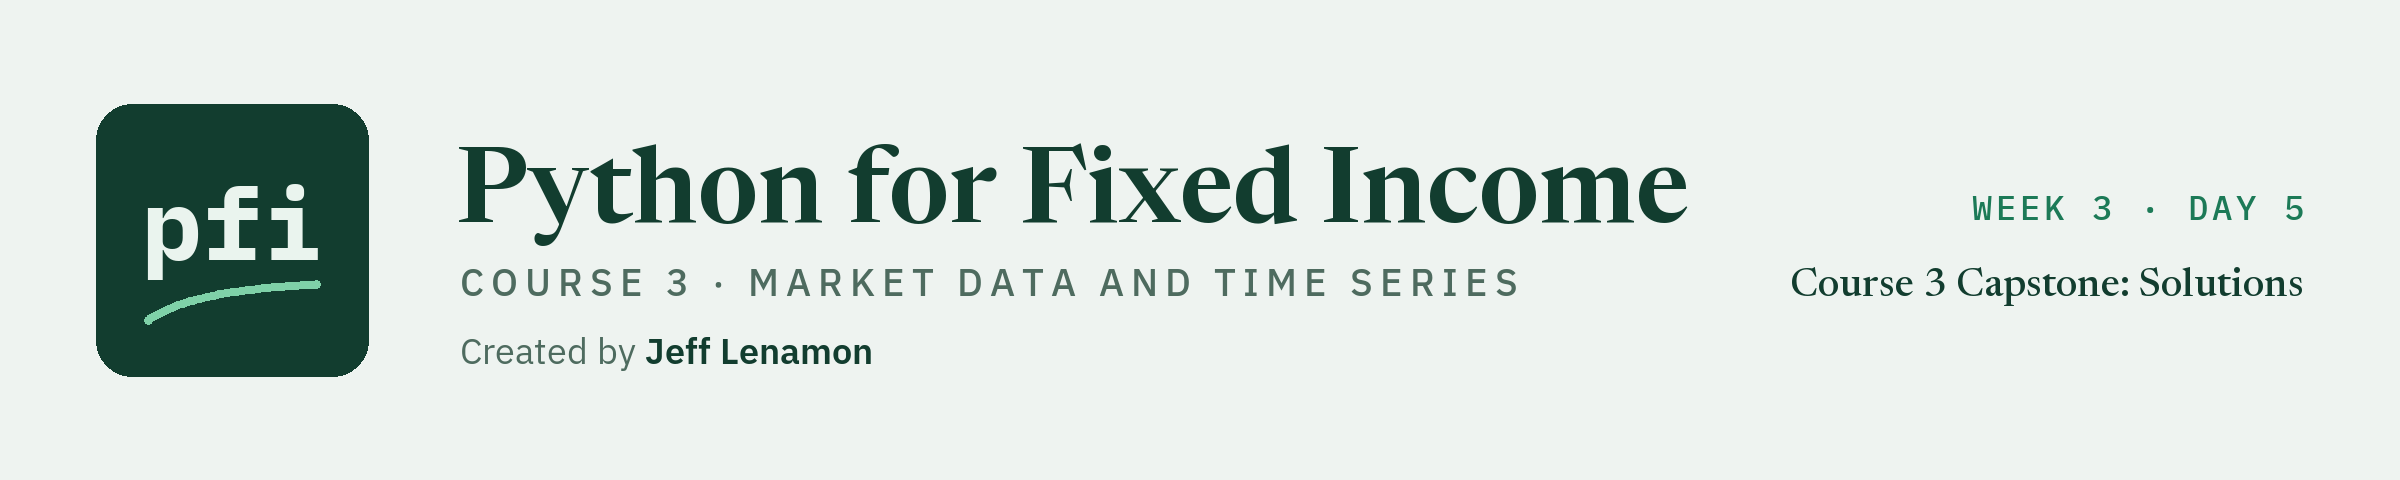

# Course 3 Capstone: Solutions

Week 3, Day 5. The worked version of the capstone: every question answered with code, its output, and what the output shows. Write your own answers and your own description first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course3_market_data/week3/day5/course3_capstone_solutions.ipynb)

## The Brief

### The scenario

You are the analyst on the credit desk, and the desk's market data vendor sends a daily extract. The history to 2026-06-30 is already clean: the Treasury par yield file and the course's synthetic credit spreads, cut at that date. The vendor's extract covers 2026-07-01 to 2026-10-02, with a cover note. The portfolio manager wants the daily snapshot for 2026-10-02, and again for 2026-09-30, built on data you have proved.

Fourteen days built the tools: your own `marketdata.py` beside `bondmath.py`, tested against Excel, and Git to keep it safe. Today you use all of them on one job, as Course 2 ended with its capstone. The extract carries data problems, planted on purpose, and nothing in this notebook says what they are. The desk's rules, the market's own calendar, and your module find them.

The Treasury yields are public data. The credit spreads are synthetic, invented for this course: they are not ICE, Moody's, or any index. The book is the synthetic September book of invented issuers.

### What to hand in

This notebook, completed and run from top to bottom, with ten deliverables:

| # | Deliverable | Where |
| --- | --- | --- |
| 1 | `marketdata.py` complete, and `pytest -q` passing with its output saved | Section 1 |
| 2 | `clean_extract(raw, source)` in `clean_extract.py`: the cleaning decisions with `assert` checks, one row per market day | Sections 2 to 5 |
| 3 | A reconciliation: the extract against the source files, column by column, every difference given a decision of `clean_extract`, and 0 unexplained | Section 6 |
| 4 | The snapshot for 2026-10-02 on the appended history, written as HTML and Excel to `snapshots/` in the work folder, read back and checked | Section 7 |
| 5 | Rerun, do not redo: `snapshot.py --as-of 2026-09-30` run with `subprocess`, and the two dates side by side | Section 8 |
| 6 | SQL: both snapshots' levels in a `snapshot_history` table of `course3.db`, queried back and compared with pandas | Section 8 |
| 7 | One Git commit for each deliverable that writes a file, then the tag `course3`; the snapshot outputs stay ignored | Every section, then Save the Day with Git |
| 8 | An AI-use log | Section 10 |
| 9 | A written description of the two dates that describes and never forecasts | Section 10 |
| 10 | Optional, with your own FRED key: the same snapshot from a fresh FRED pull, compared with the source files | Section 9 |

### How long

The course map gives the capstone one day. It is more work than one sitting. Plan on two or three.

| Sitting | Sections |
| --- | --- |
| First | 1 the module, 2 testing the extract, 3 dates and rows, 4 values |
| Second | 5 `clean_extract`, 6 the reconciliation, 7 the snapshot |
| Third | 8 the rerun and SQL, 9 live (optional), 10 the log and the description, then Git and Bring It Home |

### The rules

1. **Work in a copy.** `raw` is the file as it arrived and is never changed. Question 2.1 makes the working copy, `extract`.
2. **State every decision.** Before each fix, add a markdown cell that says what you are changing, in how many rows, and the evidence.
3. **Print the headline before and after every fix.** The setup gives you `headline()`.
4. **The market calendar is the Treasury file's own dates** (day 3), never a holiday list. A value is never filled from a neighbour (day 3): a filled value is a value the market never printed.
5. **Describe, never forecast.** Every sentence you write says what the data was, where it sits in its history, or how it changed. Nothing says where rates or spreads are going or what anyone should do. The book's change in market value is a mechanical what-if.
6. **Git only in the work folder.** Every Git command is written `!git -C "{work}" ...`, as on every day of the course.
7. **No key on the screen.** Section 9 is the only place that uses your FRED key, through the key cell. Never print it.
8. **The notebook runs from top to bottom** with Restart and Run All before you hand it in.

### What help is allowed

Every earlier notebook of the course and your notes; the documentation of pandas, matplotlib, and openpyxl; and an AI assistant, used the way the course taught: the docstring is the prompt, read the code that comes back, test it against the source files or the cover note, and keep a log as you go (question 10.1). Nothing from an employer goes into an AI tool or into Colab, and no key ever goes into one.

### How to check your work

Most questions ask you to store an answer in a variable such as `answer_2_1`. The cell after it calls `check()`, which prints `correct`, `not yet` with what you have, or `not attempted yet`. The right answers are not written anywhere in this notebook: each check holds a short code made from the right answer, and `check()` makes a code from yours in the same way and compares the two. A whole number can be given as `7` or `7.0`. A decimal is rounded to the places the question states before it is compared. Text is compared without regard to capitals or spaces at the ends, and a date is text written `YYYY-MM-DD`. Several values go in a tuple, in the order the question asks.

Your decisions change the numbers that follow. After section 4 and again after `clean_extract`, a checkpoint cell tests your table against the cover note and against the decisions the worked version made. Do not go on until it passes. Under some questions a closed block that starts "Stuck after trying?" holds the decision the checkpoint expects for one kind of problem. Leave it closed until you have made your own.

Worked answers are in `course3_capstone_solutions.ipynb` in this folder. Open it after you have written your own description.

## The Data

All files are in the repo's `data` folder, and the setup copies them into the work folder. Units: **yields in percent, spreads in basis points, dollars in the book.**

| File | What it is |
| --- | --- |
| `course3_capstone_extract.csv` | the vendor's extract for 2026-07-01 to 2026-10-02: `date`, `2 Yr`, `5 Yr`, `10 Yr`, `30 Yr`, `ig_spread_bp`, `hy_spread_bp`. One row should be one market day |
| `course3_capstone_cover_note.txt` | the vendor's note: the period, the number of market days, the columns, and the last values it sent |
| `treasury_par_yields.csv` | the U.S. Treasury's par yield curve, 2,940 market days from 2015-01-02 to 2026-10-02, public domain: the market calendar and the clean history |
| `course3_synthetic_spreads.csv` | the course's synthetic investment grade and high yield spreads, one row per date of the Treasury file |
| `holdings.csv` | the September book, as of 2026-09-30: 200 bonds of invented issuers, for the snapshot's book section (day 14) |

The history to 2026-06-30 is the Treasury file and the synthetic spreads, unchanged. The extract replaces them for its own period: the snapshot is built on the history with the cleaned extract appended. Because the course has the clean source for the extract's period too, every cleaning decision can be proved by reconciliation, not judged by eye. A real vendor's file has no such twin, and section 4 says what you would do then.

## Setup

Run the setup cells first. They are complete: do not change them. The first makes today's work folder and copies the data files into it. The next three write the reference `bondmath.py`, and the complete `marketdata.py` and `test_marketdata.py` as day 14 left them: 29 functions and 55 tests. **If you kept your own `my_bondmath` up to date, paste your own two files into those cells instead.** The capstone runs on either. Then the modules are imported, and the last setup cell loads the files and defines `headline()`, `answer_text()`, and `check()`.

Q. Set up the work folder and copy the data files into it.

In [1]:
# today's setup: modules, the course data, a fresh work folder, and the constants the live cells use
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# three packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("pytest", "pytest"), ("requests", "requests"), ("dotenv", "python-dotenv")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None
import pytest
import requests

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "treasury_par_yields.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. your own key file: in your my_bondmath folder, outside every repository. Its path is never printed.
ENV_FILE = Path.home() / "projects" / "my_bondmath" / ".env"

# 3. the two constants of the live cells
NO_KEY_MESSAGE = "Live cell skipped: no FRED key was found. Every other cell runs without one."
# ICE BofA and Moody's values stay off the screen unless you set this to True, on your own machine only
SHOW_LICENSED_VALUES = False

# 4. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course3_15_"))
os.chdir(work)

# 5. copy today's data files into the work folder
DATA_FILES = ["treasury_par_yields.csv", "course3_synthetic_spreads.csv", "course3_fred_format_dgs10.json", "course3_fred_format_dgs2.json", "course3_excel_reference.csv", "holdings.csv", "ratings.csv", "trade_blotter.csv", "course3_capstone_extract.csv", "course3_capstone_cover_note.txt"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES) or 'none'}")
print(f"pytest {pytest.__version__}, requests {requests.__version__}")

Work folder: pfi_course3_15_6idiy15k, in your temp folder
Data files from the data folder of the course repo: treasury_par_yields.csv, course3_synthetic_spreads.csv, course3_fred_format_dgs10.json, course3_fred_format_dgs2.json, course3_excel_reference.csv, holdings.csv, ratings.csv, trade_blotter.csv, course3_capstone_extract.csv, course3_capstone_cover_note.txt
pytest 9.1.1, requests 2.34.2


Q. Write `bondmath.py`, the reference copy of the module you finished in Course 2.

It is written into the work folder so that every notebook runs, in Colab too, whether or not you took Course 2. To use your own copy instead, run this line in a new cell after the next one:

```python
shutil.copy(Path.home() / "projects" / "my_bondmath" / "bondmath.py", work)
```

The saved outputs of this notebook always come from the reference copy.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


Q. Write `marketdata.py` and `test_marketdata.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile marketdata.py
"""marketdata: dated market series for fixed income, checked against Excel.

Written day by day in Python for Fixed Income, Course 3: Market Data and Time Series.

Conventions, the same in every function:
- A series has a DatetimeIndex named date: naive calendar dates (no time, no time zone), unique and ascending.
- Yields are in percent (5.29 means 5.29 percent), as Treasury and FRED publish them. Spreads are in basis points.
- Changes of yields and spreads are in basis points. Price changes are simple returns in percent.
- Windows are counted in observations (rows of the market calendar), trailing, and include the current row.
- A missing observation is NaN. It is dropped before any change or window is computed, never filled.
- A secret (an API key) is never printed, written to a file, or put in an error message.
"""
import os  # environment variables
from pathlib import Path  # file paths


def get_secret(name: str, env_file: str | Path) -> str:
    """Return a secret such as an API key, looked up in three places in a fixed order.

    Units: none; the secret is text. Convention: the first place that holds a non-empty value wins:
    1. the environment variable `name`;
    2. Colab's Secrets panel (google.colab.userdata), only when running in Colab;
    3. the .env file at `env_file`, read with dotenv.dotenv_values, which does not change os.environ.
    The value is returned and never printed. Raises RuntimeError naming the secret and the three places
    looked, never a value and never the full path of the file.
    """
    # 1. the environment: a variable set in PowerShell, or by the program that started Python
    value = os.environ.get(name)
    if value:
        return value

    # 2. Colab's Secrets panel: the import works only inside Colab
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
    if userdata is not None:
        try:
            value = userdata.get(name)
        # a secret that is not there, or one the notebook has not been given access to
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
            value = None
        if value:
            return value

    # 3. the .env file, imported here so Colab never needs python-dotenv
    env_path = Path(env_file)
    if env_path.is_file():
        from dotenv import dotenv_values
        value = dotenv_values(env_path).get(name)
        if value:
            return value

    # nothing found: say where we looked, with the file's name only (a full path shows a user name)
    raise RuntimeError(
        f"Secret {name} not found. Looked in: the environment variable {name}, "
        f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
    )


import pandas as pd  # dated series, from day 2
import requests  # HTTP, from day 2

# FRED's endpoint for the observations of one series
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"


def fred_params(series_id: str, api_key: str, start: str | None = None, end: str | None = None) -> dict:
    """The query parameters for one request to FRED's series/observations endpoint.

    Units: start and end are dates as text, YYYY-MM-DD. Convention: JSON is asked for (file_type json);
    a start or end left as None is not sent, so FRED returns the series from its first or to its last date.
    Pure: builds a dict and sends nothing. The dict holds the key, so it is never printed.
    """
    # the three parameters every request needs
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    # the optional date range
    if start is not None:
        params["observation_start"] = start
    if end is not None:
        params["observation_end"] = end
    return params


def parse_fred_observations(payload: dict, name: str) -> pd.Series:
    """Turn a FRED series/observations JSON answer into a float series.

    Units: as FRED publishes the series (percent for the Treasury and spread series).
    Convention: one value per observation, indexed by its date (a DatetimeIndex named date). FRED's
    missing marker "." becomes NaN and is kept: dropping it is a separate, visible step.
    Raises ValueError if the answer has no "observations" list.
    """
    # stop on an answer that is not a series/observations answer
    if "observations" not in payload:
        raise ValueError(f"the answer for {name} has no 'observations'; keys are {sorted(payload)}")
    observations = payload["observations"]
    # each date as a calendar date
    dates = pd.to_datetime([obs["date"] for obs in observations], format="%Y-%m-%d")
    # each value as a float; "." is FRED's mark for a day with no value, so it becomes NaN, never 0
    values = [float("nan") if obs["value"] == "." else float(obs["value"]) for obs in observations]
    series = pd.Series(values, index=dates, name=name, dtype="float64")
    series.index.name = "date"
    return series


def fred_series(series_id: str, api_key: str, start: str | None = None, end: str | None = None,
                timeout: float = 30) -> pd.Series:
    """Download one series from the FRED API: one GET with requests, then parse_fred_observations.

    Units: as FRED publishes the series. Convention: "." rows are kept as NaN, as parse_fred_observations.
    The only function in this module that uses the network.
    Errors never show the key or the URL (which holds the key):
    - it never calls response.raise_for_status(), whose message holds the full URL;
    - an answer other than HTTP 200 raises RuntimeError with the status and FRED's own error message;
    - a connection problem (requests.RequestException) raises RuntimeError naming only the exception class;
    - both are raised `from None`, so no chained traceback shows the original error and its URL.
    Raises RuntimeError if FRED answers with zero observations (FRED returns HTTP 200 with count 0 for a
    range the series does not cover).
    """
    # the request, sent once; the parameters (and the key) stay inside requests
    try:
        response = requests.get(FRED_URL, params=fred_params(series_id, api_key, start, end), timeout=timeout)
    except requests.RequestException as error:
        # the original message holds the URL with the key, so only the class name is kept
        raise RuntimeError(f"Request for {series_id} failed: {type(error).__name__}") from None

    # an answer other than 200: FRED puts its reason in "error_message"
    status = response.status_code
    if status != 200:
        try:
            error_message = response.json().get("error_message", "no error message")
        except ValueError:
            error_message = "the answer was not JSON"
        # FRED's messages do not echo the key; replace it anyway in case one ever does
        error_message = error_message.replace(api_key, "***")
        raise RuntimeError(f"FRED returned HTTP {status} for {series_id}: {error_message}") from None

    # parse, and stop on an empty answer
    series = parse_fred_observations(response.json(), series_id)
    if series.empty:
        raise RuntimeError(f"FRED returned no observations for {series_id} (start {start}, end {end})")
    return series


def _check_index(index: pd.Index, what: str) -> None:
    """Stop unless `index` is a DatetimeIndex with unique dates in ascending order.

    A helper for the functions below (the leading underscore marks it as not part of the module's API).
    """
    if not isinstance(index, pd.DatetimeIndex):
        raise ValueError(f"{what} must have a DatetimeIndex, not {type(index).__name__}")
    if not index.is_unique:
        raise ValueError(f"{what} has repeated dates, for example {index[index.duplicated()][0].date()}")
    if not index.is_monotonic_increasing:
        raise ValueError(f"{what} dates are not in ascending order")


def missing_weekdays(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """The weekdays from the first date to the last that have no row.

    Units: dates. Convention: a weekday is Monday to Friday; no holiday calendar is used, so the result is
    every weekday the data skipped (holidays and any other closure). Weekends are never counted.
    Raises ValueError on an index that is not unique and ascending dates.
    """
    _check_index(index, "index")
    # every Monday to Friday in the span
    weekdays = pd.bdate_range(index[0], index[-1])
    # the ones with no row
    missing = weekdays.difference(index)
    missing.name = "date"
    return missing


def align(series: dict[str, pd.Series], how: str = "inner") -> pd.DataFrame:
    """Put several dated series side by side, one column each, joined on date.

    Units: each column keeps its own units. Convention: how="inner" keeps the dates every series has;
    how="outer" keeps every date any series has and leaves NaN where a series has no row. Nothing is filled.
    Raises ValueError for any other `how`, or for a series whose index is not unique ascending dates.
    """
    # stop on a join the course does not use
    if how not in ("inner", "outer"):
        raise ValueError(f"how must be 'inner' or 'outer', not {how!r}")
    for name, values in series.items():
        _check_index(values.index, name)
    # one column per series, named by its key
    frame = pd.concat(series, axis=1, join=how)
    # an outer join can mix the order of dates, so sort them
    frame = frame.sort_index()
    frame.index.name = "date"
    return frame


def stale_runs(series: pd.Series, min_length: int = 3) -> pd.DataFrame:
    """Runs of the same value repeated on consecutive observations: a sign of a value that stopped updating.

    Units: `value` has the series' units, `length` counts observations. Convention: consecutive means
    consecutive rows, whatever the calendar gap. One row per run of at least `min_length` identical values,
    with columns start, end, length, value.
    Raises ValueError if min_length is below 2, the series has missing values (drop them first), or its index
    is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if min_length < 2:
        raise ValueError(f"min_length must be at least 2, not {min_length}")
    if series.isna().any():
        raise ValueError(f"series has {series.isna().sum()} missing values; drop them first with .dropna()")
    # a new run starts wherever the value differs from the row before
    run_id = (series != series.shift()).cumsum()
    runs = []
    for _, run in series.groupby(run_id):
        # keep runs long enough to report
        if len(run) >= min_length:
            runs.append({"start": run.index[0], "end": run.index[-1], "length": len(run), "value": run.iloc[0]})
    return pd.DataFrame(runs, columns=["start", "end", "length", "value"])


def _check_series(series: pd.Series, what: str) -> None:
    """Stop unless `series` has unique ascending dates and no missing values (a helper, not part of the API)."""
    _check_index(series.index, what)
    if series.isna().any():
        raise ValueError(f"{what} has {series.isna().sum()} missing values; drop them first with .dropna()")


def last_per_period(data: pd.Series | pd.DataFrame, freq: str) -> pd.Series | pd.DataFrame:
    """The last observation in each week or month, labelled by the date of that observation.

    Units: unchanged. Convention: freq "W-FRI" is the week ending Friday, "ME" the calendar month. Each
    period's row is the last row the data has in it, kept with its own date: September 2026 is labelled
    2026-09-30, and the week of Good Friday 2025 (no row on Friday 2025-04-18) is labelled Thursday 2025-04-17.
    pandas' resample(freq).last() labels by the period end instead. A Series must have no missing values;
    a DataFrame's rows are taken as they are, so a tenor with no value that day stays NaN.
    Raises ValueError for any other freq, or for an index that is not unique ascending dates.
    """
    # the two periods the course uses, with pandas' name for each period
    periods = {"W-FRI": "W-FRI", "ME": "M"}
    if freq not in periods:
        raise ValueError(f"freq must be 'W-FRI' or 'ME', not {freq!r}")
    if isinstance(data, pd.Series):
        _check_series(data, "data")
    else:
        _check_index(data.index, "data")
    # the period each row belongs to
    period_of_row = data.index.to_period(periods[freq])
    # the position of the last row in each period
    positions = pd.Series(range(len(data)), index=data.index).groupby(period_of_row).max()
    # those rows, with their own dates
    return data.iloc[positions.to_numpy()]


def value_as_of(series: pd.Series, as_of) -> tuple[pd.Timestamp, float]:
    """The date and value of the last observation on or before `as_of`.

    Units: the value has the series' units. Convention: the as-of value; on a holiday or weekend it is
    the previous market day's value. Excel: =XLOOKUP(as_of, dates, values, , -1).
    Raises ValueError if as_of is before the first observation, the series has missing values, or its
    index is not unique ascending dates.
    """
    _check_series(series, "series")
    as_of = pd.Timestamp(as_of)
    # stop before the start: there is no value to carry
    if as_of < series.index[0]:
        raise ValueError(f"{as_of.date()} is before the first observation, {series.index[0].date()}")
    # the position of the last date on or before as_of
    position = series.index.searchsorted(as_of, side="right") - 1
    return series.index[position], float(series.iloc[position])


from datetime import date, datetime  # the cache file's date, from day 5

# FRED's Treasury constant maturity series and the Treasury file's column for each
FRED_TREASURY = {
    "DGS1MO": "1 Mo", "DGS3MO": "3 Mo", "DGS6MO": "6 Mo", "DGS1": "1 Yr", "DGS2": "2 Yr", "DGS3": "3 Yr",
    "DGS5": "5 Yr", "DGS7": "7 Yr", "DGS10": "10 Yr", "DGS20": "20 Yr", "DGS30": "30 Yr",
}

# series IDs whose data the provider licenses: never cached, never written to a file
LICENSED_PREFIXES = ("BAML", "BAA", "AAA", "DBAA", "DAAA")


def write_cache(series: pd.Series, cache_dir: Path) -> Path:
    """Write a series to cache_dir / "<series name>.csv" and return the path.

    Units: unchanged. Convention: one row per date, the dates as YYYY-MM-DD and every float at full
    precision (no float_format), so read_cache gives back exactly the same numbers. NaN rows are kept, empty.
    Raises ValueError if the series has no name or its index is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if series.name is None:
        raise ValueError("series must have a name: it becomes the file name")
    # the folder is created the first time
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{series.name}.csv"
    # LF line endings, so the file is the same on Windows and in Colab
    series.to_csv(path, index_label="date", lineterminator="\n")
    return path


def read_cache(series_id: str, cache_dir: Path) -> pd.Series:
    """Read a series written by write_cache.

    Units: as written. Convention: a float series named series_id with a DatetimeIndex named date. The file
    is read with float_precision="round_trip": pandas' default number parser is fast but can miss the last
    digit (1.5666666666666667 comes back as 1.5666666666666669), and a cache must give back what it was given.
    Raises FileNotFoundError if the cache has no file for series_id.
    """
    path = Path(cache_dir) / f"{series_id}.csv"
    if not path.is_file():
        raise FileNotFoundError(f"no cache file {path.name} in the folder {Path(cache_dir).name}")
    frame = pd.read_csv(path, parse_dates=["date"], index_col="date", float_precision="round_trip")
    return frame[series_id].astype("float64")


def cached_fred_series(series_id: str, api_key: str, cache_dir: Path, start: str | None = None) -> pd.Series:
    """A FRED series from today's cache file if there is one, otherwise from FRED, then cached.

    Units: as FRED publishes the series. Convention: the cache file counts as fresh if it was written today
    (the computer's local date); otherwise fred_series downloads the series from `start` and write_cache
    saves it. A fresh file is returned as it is, whatever `start` it was downloaded with.
    Raises ValueError for a series ID that starts with one of LICENSED_PREFIXES: those providers' terms do
    not allow storing their data. The list covers this course's licensed series; it is not a general
    licence check, and any other series' terms are yours to read.
    """
    # refuse a licensed series before anything is downloaded or written
    if series_id.startswith(LICENSED_PREFIXES):
        raise ValueError(f"{series_id} is licensed data (prefix in LICENSED_PREFIXES): its terms do not allow "
                         f"storing it, so it is never cached. Use fred_series and keep it in memory.")
    path = Path(cache_dir) / f"{series_id}.csv"
    # today's file is fresh: no request at all
    if path.is_file() and datetime.fromtimestamp(path.stat().st_mtime).date() == date.today():
        return read_cache(series_id, cache_dir)
    # otherwise one request, then save it for the rest of the day
    series = fred_series(series_id, api_key, start=start)
    write_cache(series, cache_dir)
    return series


def change_bp(series: pd.Series, periods: int = 1, percent_units: bool = True) -> pd.Series:
    """Change over `periods` observations, in basis points.

    Units: the result is in bp. percent_units=True for a series in percent (a yield): (x_t - x_{t-k}) x 100.
    percent_units=False for a series already in bp (a spread): x_t - x_{t-k}.
    Convention: k rows back, whatever the calendar gap (the Tuesday after a Monday holiday is a change from
    Friday). The first `periods` values are NaN. Never a percent change of a yield or spread level.
    Excel: =(B3-B2)*100 for a yield in percent.
    Raises ValueError if periods is below 1, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if periods < 1:
        raise ValueError(f"periods must be at least 1, not {periods}")
    # the difference from k rows back
    difference = series - series.shift(periods)
    # percent to basis points: 1 percent is 100 bp
    return difference * 100 if percent_units else difference


def return_pct(series: pd.Series, periods: int = 1) -> pd.Series:
    """Simple return over `periods` observations, in percent, for a price series.

    Units: prices in, percent out. Convention: (P_t / P_{t-k} - 1) x 100, k rows back; no log returns.
    The first `periods` values are NaN. Excel: =(C3/C2-1)*100
    Raises ValueError if periods is below 1, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if periods < 1:
        raise ValueError(f"periods must be at least 1, not {periods}")
    # price now over price k rows back, less one, in percent
    return (series / series.shift(periods) - 1) * 100


def change_since_bp(series: pd.Series, as_of, since, percent_units: bool = True) -> float:
    """Change from the as-of value at `since` to the as-of value at `as_of`, in basis points.

    Units: the result is in bp; percent_units as change_bp. Convention: each end is the last observation
    on or before its date (value_as_of), so a `since` on a holiday or weekend uses the market day before it.
    One week back is as_of - 7 days; one month back is as_of - pd.DateOffset(months=1).
    Excel: =(XLOOKUP(as_of,A:A,B:B,,-1)-XLOOKUP(since,A:A,B:B,,-1))*100
    Raises ValueError if since is after as_of or before the first observation.
    """
    if pd.Timestamp(since) > pd.Timestamp(as_of):
        raise ValueError(f"since ({pd.Timestamp(since).date()}) must not be after as_of ({pd.Timestamp(as_of).date()})")
    # the as-of value at each end
    _, value_now = value_as_of(series, as_of)
    _, value_then = value_as_of(series, since)
    difference = value_now - value_then
    return difference * 100 if percent_units else difference


import math  # the annualising factor, from day 7

# the course's annualising convention for daily figures; other desks use other factors
TRADING_DAYS_PER_YEAR = 252


def rolling_vol_bp(changes_bp: pd.Series, window: int = 63, annualise: bool = False) -> pd.Series:
    """Rolling volatility of daily changes in bp: the sample standard deviation over a trailing window.

    Units: changes in bp in, bp out (per day; per year when annualise=True).
    Convention: the window ending on date t holds t and the window - 1 rows before it (rows, not calendar
    days); min_periods = window, so the first window - 1 values are NaN; sample standard deviation (ddof=1,
    Excel STDEV.S). annualise=True multiplies by sqrt(252), a convention.
    Excel: =STDEV.S(F2:F64) filled down, and =STDEV.S(F2:F64)*SQRT(252)
    Raises ValueError if window is below 2, the changes have missing values (the first change is NaN, so pass
    change_bp(...).dropna()), or the index is not unique ascending dates.
    """
    _check_series(changes_bp, "changes_bp")
    if window < 2:
        raise ValueError(f"window must be at least 2 rows, not {window}")
    # trailing window of `window` rows, full windows only, sample standard deviation
    vol = changes_bp.rolling(window, min_periods=window).std(ddof=1)
    # per year only when asked for
    if annualise:
        vol = vol * math.sqrt(TRADING_DAYS_PER_YEAR)
    return vol


def rolling_zscore(series: pd.Series, window: int = 252) -> pd.Series:
    """Where each value sits in its own trailing window, in standard deviations from the window's mean.

    Units: none (a number of standard deviations). Convention: z_t = (x_t - mean) / sample standard deviation,
    both over the trailing window that includes x_t (window rows, min_periods = window, ddof=1). NaN where the
    window's standard deviation is 0 (a flat, stale stretch). Describes position only; it is not a signal.
    Excel: =STANDARDIZE(B253,AVERAGE(B2:B253),STDEV.S(B2:B253)) filled down
    Raises ValueError if window is below 2, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if window < 2:
        raise ValueError(f"window must be at least 2 rows, not {window}")
    # the trailing window's mean and sample standard deviation, today included
    mean = series.rolling(window, min_periods=window).mean()
    std = series.rolling(window, min_periods=window).std(ddof=1)
    # a flat window has no spread to measure against
    std = std.where(std != 0)
    return (series - mean) / std


def rolling_percentile_rank(series: pd.Series, window: int = 252) -> pd.Series:
    """The share of the trailing window at or below each value, in percent.

    Units: percent, above 0 up to 100. Convention: 100 x (number of window values at or below x_t) / window,
    over the trailing window that includes x_t (min_periods = window). Ties count as at or below.
    Values are compared at 15 significant digits, as Excel's COUNTIF compares them: in binary arithmetic
    (4.13 - 3.81) x 100 is 31.999999999999986 and (4.12 - 3.80) x 100 is 32.00000000000003, and the two count
    as a tie at 32 bp.
    Excel: =COUNTIF(B2:B253,"<="&B253)/COUNT(B2:B253)*100 filled down. Excel's PERCENTRANK.INC is a
    different measure (values strictly below over n - 1, cut to 3 digits).
    Raises ValueError if window is below 2, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if window < 2:
        raise ValueError(f"window must be at least 2 rows, not {window}")
    # 15 significant digits, so arithmetic noise in the last binary digit does not break a tie
    rounded = series.map(lambda value: float(f"{value:.15g}"))
    # method="max" gives each value the count of window values at or below it; pct=True divides by the count
    return rounded.rolling(window, min_periods=window).rank(pct=True, method="max") * 100


def slope_bp(curve: pd.DataFrame, short: str, long: str) -> pd.Series:
    """A curve slope in basis points: the long tenor's yield less the short tenor's.

    Units: yields in percent in, bp out. Convention: (curve[long] - curve[short]) x 100, named short then
    long: 2s10s is slope_bp(curve, "2 Yr", "10 Yr"). Positive when the longer yield is higher.
    Excel: =(L2-I2)*100 with the 10 Yr in L and the 2 Yr in I.
    Raises ValueError if a tenor is not a column of curve, or the index is not unique ascending dates.
    """
    _check_index(curve.index, "curve")
    for tenor in (short, long):
        if tenor not in curve.columns:
            raise ValueError(f"{tenor!r} is not a column of curve")
    # long less short, percent to bp
    return ((curve[long] - curve[short]) * 100).rename(f"{short} to {long} slope, bp")


def butterfly_bp(curve: pd.DataFrame, short: str, belly: str, long: str) -> pd.Series:
    """A butterfly in basis points: twice the belly's yield less both wings.

    Units: yields in percent in, bp out. Convention: (2 x belly - short - long) x 100, named short, belly,
    long: 2s5s10s is butterfly_bp(curve, "2 Yr", "5 Yr", "10 Yr"). Positive when the belly yields more than
    the average of the wings. Some desks quote the opposite sign.
    Excel: =(2*J2-I2-L2)*100 with the 5 Yr in J.
    Raises ValueError if a tenor is not a column of curve, or the index is not unique ascending dates.
    """
    _check_index(curve.index, "curve")
    for tenor in (short, belly, long):
        if tenor not in curve.columns:
            raise ValueError(f"{tenor!r} is not a column of curve")
    # twice the belly, less each wing, percent to bp
    return ((2 * curve[belly] - curve[short] - curve[long]) * 100).rename(f"{short} {belly} {long} fly, bp")


def fly_weights(dv01_short: float, dv01_belly: float, dv01_long: float) -> tuple[float, float, float]:
    """Face amounts for a DV01-neutral butterfly, per 1 of belly face.

    Units: DV01s in any one unit (price points per 100 of face per bp from bondmath.dv01); weights are face
    per 1 of belly face. Convention: the belly's face is 1; each wing's face is set so its DV01 is half the
    belly's: w_short = 0.5 x dv01_belly / dv01_short and w_long = 0.5 x dv01_belly / dv01_long. With the
    belly on one side and both wings on the other, the DV01s net to zero. Arithmetic, not a position.
    Returns (w_short, 1.0, w_long). Raises ValueError if a DV01 is not positive.
    """
    # a DV01 of zero or less cannot be balanced
    for label, dv01 in (("dv01_short", dv01_short), ("dv01_belly", dv01_belly), ("dv01_long", dv01_long)):
        if dv01 <= 0:
            raise ValueError(f"{label} must be positive, not {dv01}")
    # half the belly's DV01 on each wing
    w_short = 0.5 * dv01_belly / dv01_short
    w_long = 0.5 * dv01_belly / dv01_long
    return w_short, 1.0, w_long


def summary_table(data: pd.DataFrame, as_of, units: dict[str, str], window: int = 252) -> pd.DataFrame:
    """One row per column of `data`: the level and every measure as of one date, from rows on or before it.

    Units: units[column] is "pct" for a series in percent (a yield) or "bp" for a series in bp (a spread,
    slope, or fly). level is in that unit; chg_1d_bp, chg_1w_bp, chg_1m_bp are in bp; zscore has no unit;
    pct_rank is in percent.
    Convention: each column's missing values are dropped and only rows on or before as_of are used, so a later
    row can never change the table. level is the as-of value; chg_1d_bp is the change from the previous
    observation; chg_1w_bp and chg_1m_bp are change_since_bp from as_of - 7 days and as_of - 1 month;
    zscore and pct_rank are rolling_zscore and rolling_percentile_rank over `window` rows, today included.
    Raises ValueError if a column has no unit or a unit other than "pct" or "bp", or the index is not unique
    ascending dates.
    """
    _check_index(data.index, "data")
    as_of = pd.Timestamp(as_of)
    rows = {}
    for column in data.columns:
        # the unit decides whether changes are multiplied by 100
        unit = units.get(column)
        if unit not in ("pct", "bp"):
            raise ValueError(f"units[{column!r}] must be 'pct' or 'bp', not {unit!r}")
        percent_units = unit == "pct"
        # only what was known on the as-of date, missing values dropped
        series = data[column].loc[:as_of].dropna()
        _, level = value_as_of(series, as_of)
        rows[column] = {
            "unit": unit,
            "level": level,
            "chg_1d_bp": change_bp(series, 1, percent_units).iloc[-1],
            "chg_1w_bp": change_since_bp(series, as_of, as_of - pd.Timedelta(days=7), percent_units),
            "chg_1m_bp": change_since_bp(series, as_of, as_of - pd.DateOffset(months=1), percent_units),
            "zscore": rolling_zscore(series, window).iloc[-1],
            "pct_rank": rolling_percentile_rank(series, window).iloc[-1],
        }
    # one row per series
    table = pd.DataFrame.from_dict(rows, orient="index")
    table.index.name = "series"
    return table


import sqlite3  # a database in one file, from day 11
from contextlib import closing  # closes a connection at the end of a with block, from day 11


def load_tables(db_path: Path, tables: dict[str, Path]) -> dict[str, int]:
    """Write each CSV file to a table of the SQLite database at db_path, and return each table's row count.

    Units: unchanged; dates stay ISO text (YYYY-MM-DD), which SQLite sorts and compares in date order.
    Convention: tables maps a table name to a CSV path; an existing table of that name is replaced. Each
    count is read back from the database with SELECT COUNT(*) and checked against the CSV's rows.
    Raises ValueError for a table name that is not a plain identifier (letters, digits, underscore), and
    RuntimeError if a table's count differs from its CSV's.
    """
    counts = {}
    # sqlite3's own `with` commits but does not close, so closing() closes the file at the end
    with closing(sqlite3.connect(db_path)) as connection:
        for name, csv_path in tables.items():
            # a table name cannot be a ? parameter, so only plain names are allowed
            if not name.isidentifier():
                raise ValueError(f"table name {name!r} must be letters, digits, and underscores")
            frame = pd.read_csv(csv_path)
            frame.to_sql(name, connection, if_exists="replace", index=False)
            connection.commit()
            # read the count back from the database and check it
            count = connection.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
            if count != len(frame):
                raise RuntimeError(f"table {name} has {count} rows but {Path(csv_path).name} has {len(frame)}")
            counts[name] = count
    return counts


def run_query(db_path: Path, sql: str, params: tuple = ()) -> pd.DataFrame:
    """Run one SQL query against the SQLite database at db_path and return the result.

    Units: as stored. Convention: values go in through ? parameters (`params`), never pasted into the SQL
    text with an f-string. The connection is closed when the query is done.
    Raises FileNotFoundError if db_path does not exist (sqlite3 would otherwise create an empty database).
    """
    if not Path(db_path).is_file():
        raise FileNotFoundError(f"no database file {Path(db_path).name}")
    with closing(sqlite3.connect(db_path)) as connection:
        return pd.read_sql_query(sql, connection, params=params)


def assert_same_rows(left: pd.DataFrame, right: pd.DataFrame, sort_by: list[str]) -> None:
    """Check that two tables hold the same rows, in any order: a SQL result against its pandas equivalent.

    Units: unchanged. Convention: the same column names; both sorted by `sort_by`, index reset, columns in
    left's order; text and whole numbers equal exactly, floats within rtol=1e-12 and atol=1e-9 (SQLite and
    pandas may add in a different order). An integer column on one side may be a float column on the other.
    Raises AssertionError with pandas' message on the first difference.
    """
    # the same columns, whatever their order
    if set(left.columns) != set(right.columns):
        raise AssertionError(f"columns differ: left only {sorted(set(left.columns) - set(right.columns))}, "
                             f"right only {sorted(set(right.columns) - set(left.columns))}")
    # the same order of rows and columns on both sides
    left_sorted = left.sort_values(sort_by).reset_index(drop=True)
    right_sorted = right[list(left.columns)].sort_values(sort_by).reset_index(drop=True)
    pd.testing.assert_frame_equal(left_sorted, right_sorted, check_dtype=False, rtol=1e-12, atol=1e-9)


import json  # an assistant's JSON reply, from day 13


def parse_json_reply(text: str, required: list[str]) -> dict:
    """Read an AI assistant's reply that was asked to answer in JSON, and check it has the fields asked for.

    Units: none. Convention: the whole reply must be one JSON object (json.loads); extra fields are kept.
    Raises ValueError if the text is not JSON, is JSON but not an object, or lacks any field in `required`
    (the message names every missing field).
    """
    # parse the reply; a reply with prose around the JSON fails here
    try:
        reply = json.loads(text)
    except json.JSONDecodeError as error:
        raise ValueError(f"the reply is not valid JSON: {error.msg} at line {error.lineno}, column {error.colno}") from error
    # an object, not a list or a bare number
    if not isinstance(reply, dict):
        raise ValueError(f"the reply is JSON but not an object: it is a {type(reply).__name__}")
    # every field asked for
    missing = [field for field in required if field not in reply]
    if missing:
        raise ValueError(f"the reply is missing {', '.join(missing)}")
    return reply


import base64  # charts embedded in the HTML, from day 14
import html  # safe text in the HTML, from day 14
import io  # a chart written to memory, from day 14

from matplotlib.figure import Figure  # the type of a chart, from day 14

import bondmath  # the book section, from day 14

# the Treasury file's tenor labels and their years
TENOR_YEARS = {"1 Mo": 1 / 12, "1.5 Month": 1.5 / 12, "2 Mo": 2 / 12, "3 Mo": 0.25, "4 Mo": 4 / 12, "6 Mo": 0.5,
               "1 Yr": 1.0, "2 Yr": 2.0, "3 Yr": 3.0, "5 Yr": 5.0, "7 Yr": 7.0, "10 Yr": 10.0, "20 Yr": 20.0,
               "30 Yr": 30.0}
# the slopes (short, long) and flies (short, belly, long) on the snapshot
SLOPES = {"2s10s": ("2 Yr", "10 Yr"), "5s30s": ("5 Yr", "30 Yr"), "3m10y": ("3 Mo", "10 Yr")}
FLIES = {"2s5s10s": ("2 Yr", "5 Yr", "10 Yr"), "5s10s30s": ("5 Yr", "10 Yr", "30 Yr")}
DISCLAIMER = ("This course is educational content created in a personal capacity. Nothing here is investment "
              "advice or a recommendation to buy or sell any security. All portfolio data is synthetic.")
SOURCES = ("Treasury yields: U.S. Department of the Treasury, Daily Treasury Par Yield Curve Rates (public domain). "
           "Credit spreads: course3_synthetic_spreads.csv, synthetic, invented for this course, not ICE, Moody's, "
           "or any index. Book: holdings.csv, a synthetic book of invented issuers.")


def _book_section(book: pd.DataFrame, curve: pd.DataFrame) -> pd.DataFrame:
    """The book's position DV01 and the mechanical change in market value from the day's curve change, by
    sector and by rating bucket, then the total (a helper for snapshot_tables, not part of the API)."""
    settlement_dates = book["as_of_date"].unique()
    if len(settlement_dates) != 1:
        raise ValueError(f"the book must have one as_of_date, not {len(settlement_dates)}")
    settlement = date.fromisoformat(settlement_dates[0])
    # the day's curve change in bp, by tenor in years, for interpolation
    tenors_years = curve["years"].tolist()
    changes_bp = curve["chg_bp"].tolist()
    rows = []
    for bond in book.itertuples():
        maturity = date.fromisoformat(bond.maturity)
        # position DV01 in dollars per bp: DV01 per 100 of face times face / 100
        dv01_usd = bondmath.dv01(settlement, maturity, bond.coupon, bond.yield_pct) * bond.par_held / 100
        # the day's curve change at the bond's maturity, applied to its yield: a what-if, not a forecast
        shift_bp = bondmath.interpolate_yield(bondmath.years_to_maturity(settlement, maturity), tenors_years, changes_bp)
        before = bondmath.dirty_price(settlement, maturity, bond.coupon, bond.yield_pct)
        after = bondmath.dirty_price(settlement, maturity, bond.coupon, bond.yield_pct + shift_bp / 100)
        rows.append({"sector": bond.sector, "bucket": bond.rating.rstrip("+-"), "face_usd": bond.par_held,
                     "market_value_usd": bond.market_value, "dv01_usd": dv01_usd,
                     "mv_change_usd": (after - before) * bond.par_held / 100})
    positions = pd.DataFrame(rows)
    sums = {"bonds": ("face_usd", "size"), "face_usd": ("face_usd", "sum"),
            "market_value_usd": ("market_value_usd", "sum"), "dv01_usd": ("dv01_usd", "sum"),
            "mv_change_usd": ("mv_change_usd", "sum")}
    # by sector, then by rating bucket, then the whole book
    by_sector = positions.groupby("sector").agg(**sums).reset_index(names="group").assign(by="sector")
    by_bucket = positions.groupby("bucket").agg(**sums).reset_index(names="group").assign(by="rating bucket")
    total = pd.DataFrame([{"by": "total", "group": "book"} | {k: positions[c].agg(f) for k, (c, f) in sums.items()}])
    table = pd.concat([by_sector, by_bucket, total], ignore_index=True)
    return table[["by", "group", "bonds", "face_usd", "market_value_usd", "dv01_usd", "mv_change_usd"]]


def snapshot_tables(market: pd.DataFrame, book: pd.DataFrame, as_of, units: dict[str, str],
                    window: int = 252) -> dict[str, pd.DataFrame]:
    """The tables of a one-page daily market snapshot for `as_of`, from rows on or before it only.

    Units: yields in percent, spreads, slopes, flies, and changes in bp, dollars in the book table.
    Convention:
    - levels: summary_table of the columns named in `units`;
    - curve: each tenor's yield on as_of and on the previous observation, and the change in bp;
    - slopes_flies: summary_table of 2s10s, 5s30s, 3m10y, 2s5s10s, and 5s10s30s (all in bp);
    - book: the book's position DV01 (bondmath.dv01 at the book's own as_of_date) and the mechanical change
      in market value if each bond's yield moved by the day's change in the par curve, interpolated at its
      maturity with bondmath.interpolate_yield; by sector, by rating bucket, and in total. A what-if.
    Each table's attrs["as_of"] holds the date as YYYY-MM-DD, for the writers.
    Raises ValueError if as_of is not a market date (a date with a row in `market`).
    """
    _check_index(market.index, "market")
    as_of = pd.Timestamp(as_of)
    if as_of not in market.index:
        raise ValueError(f"{as_of.date()} is not a market date: market has no row for it")
    # only what was known on the as-of date
    known = market.loc[:as_of]
    levels = summary_table(known[list(units)], as_of, units, window)

    # the curve on as_of and on the previous observation
    tenors = [column for column in known.columns if column in TENOR_YEARS]
    previous_date = known.index[-2]
    curve = pd.DataFrame({"years": [TENOR_YEARS[t] for t in tenors],
                          "previous_pct": known.loc[previous_date, tenors].to_numpy(),
                          "as_of_pct": known.loc[as_of, tenors].to_numpy()}, index=pd.Index(tenors, name="tenor"))
    curve["chg_bp"] = (curve["as_of_pct"] - curve["previous_pct"]) * 100
    # a tenor with no value on either day is left out; the rest in order of years
    curve = curve.dropna().sort_values("years")

    # slopes and flies, then their summary
    shapes = pd.DataFrame({name: slope_bp(known, short, long) for name, (short, long) in SLOPES.items()}
                          | {name: butterfly_bp(known, *legs) for name, legs in FLIES.items()})
    slopes_flies = summary_table(shapes, as_of, {name: "bp" for name in shapes.columns}, window)

    tables = {"levels": levels, "curve": curve, "slopes_flies": slopes_flies, "book": _book_section(book, curve)}
    for table in tables.values():
        table.attrs["as_of"] = as_of.strftime("%Y-%m-%d")
    return tables


def write_snapshot_html(tables: dict[str, pd.DataFrame], figures: dict[str, Figure], path: Path, title: str) -> Path:
    """Write the snapshot as one self-contained HTML file and return its path.

    Units: as in the tables (numbers shown to 2 decimals). Convention: the title, the as-of date (from the
    tables' attrs, set by snapshot_tables), the disclaimer, each table as DataFrame.to_html, each chart as a
    PNG embedded in base64 (no separate image files), the data sources, and the synthetic label. Describes the
    data; it contains no forecast and no recommendation. Uses no template library.
    Raises ValueError if the tables carry no as-of date.
    """
    as_of = tables["levels"].attrs.get("as_of")
    if as_of is None:
        raise ValueError("the tables carry no as-of date; build them with snapshot_tables")
    parts = [f"<h1>{html.escape(title)}</h1>", f"<p>As of {as_of}.</p>",
             f"<p><em>{html.escape(DISCLAIMER)}</em></p>"]
    # each table, numbers to 2 decimals with thousands separators
    for name, table in tables.items():
        parts.append(f"<h2>{html.escape(name)}</h2>")
        parts.append(table.to_html(float_format="{:,.2f}".format))
    # each chart as a PNG held inside the file
    for name, figure in figures.items():
        buffer = io.BytesIO()
        figure.savefig(buffer, format="png", dpi=100)
        encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
        parts.append(f"<h2>{html.escape(name)}</h2>")
        parts.append(f'<img alt="{html.escape(name)}" src="data:image/png;base64,{encoded}">')
    parts.append(f"<p>{html.escape(SOURCES)}</p>")
    parts.append("<p>The credit spreads and the book are synthetic.</p>")
    page = ("<!DOCTYPE html>\n<html lang=\"en\">\n<head>\n<meta charset=\"utf-8\">\n"
            f"<title>{html.escape(title)}</title>\n</head>\n<body>\n" + "\n".join(parts) + "\n</body>\n</html>\n")
    path = Path(path)
    path.write_text(page, encoding="utf-8", newline="\n")
    return path


def write_snapshot_excel(tables: dict[str, pd.DataFrame], path: Path) -> Path:
    """Write the snapshot tables to one Excel workbook, one sheet per table, and return its path.

    Units: as in the tables. Convention: pd.ExcelWriter with openpyxl; each sheet is named by its table's key
    and holds the table with its index.
    """
    path = Path(path)
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for name, table in tables.items():
            table.to_excel(writer, sheet_name=name)
    return path

Writing marketdata.py


In [4]:
%%writefile test_marketdata.py
"""Tests for marketdata.py.

Expected values come from Excel (course3_excel_reference.csv in this folder), from the course's data files, or
from small hand examples. No test touches the network or needs a real key: the only key is the course's fake one.
Run from this folder with:  python -m pytest
"""
import pytest

import marketdata as md

# the course's fake key: 32 lowercase letters, the shape FRED expects, obviously not a key
FAKE_KEY = "fakefakefakefakefakefakefakefake"
# the demo name; never FRED_API_KEY, because get_secret checks the environment first
DEMO_NAME = "DEMO_API_KEY"


def test_get_secret_reads_environment(monkeypatch, tmp_path):
    # monkeypatch sets the variable for this test only and removes it afterwards
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=tmp_path / ".env") == FAKE_KEY


def test_get_secret_reads_env_file(monkeypatch, tmp_path):
    # no variable in the environment, so the file is used
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}={FAKE_KEY}\n", encoding="utf-8")
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_environment_wins(monkeypatch, tmp_path):
    # both places hold a value: the environment comes first
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}=value-from-the-file\n", encoding="utf-8")
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_missing_raises_without_value(monkeypatch, tmp_path):
    # the file holds a different secret; the one asked for is nowhere
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"OTHER_API_KEY={FAKE_KEY}\n", encoding="utf-8")
    with pytest.raises(RuntimeError) as caught:
        md.get_secret(DEMO_NAME, env_file=env_file)
    message = str(caught.value)
    # the message names the secret and the places looked, and holds no value and no folder
    assert DEMO_NAME in message and "environment" in message and ".env" in message
    assert FAKE_KEY not in message
    assert str(tmp_path) not in message


import json  # the FRED-format samples, from day 2
import math  # NaN checks, from day 2
import traceback  # what a printed error would show, from day 2
from pathlib import Path  # this folder, from day 2

import pandas as pd  # dated series, from day 2
import requests  # its exception classes, from day 2

# the data files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_sample(series_id: str) -> dict:
    """A FRED-format sample from this folder: Treasury values in FRED's JSON layout, no network."""
    return json.loads((HERE / f"course3_fred_format_{series_id.lower()}.json").read_text(encoding="utf-8"))


class FakeResponse:
    """A stand-in for requests.Response: a status code, a JSON body, and a URL holding the key, no network."""

    def __init__(self, status_code: int, payload: dict):
        self.status_code = status_code
        self.payload = payload
        # a real response's URL holds the key; if fred_series ever printed it, the tests below would catch it
        self.url = f"{md.FRED_URL}?series_id=DGS10&api_key={FAKE_KEY}&file_type=json"

    def json(self) -> dict:
        return self.payload


def test_params_hold_series_and_json():
    params = md.fred_params("DGS10", FAKE_KEY, start="2015-01-01")
    assert params == {"series_id": "DGS10", "api_key": FAKE_KEY, "file_type": "json",
                      "observation_start": "2015-01-01"}
    # no end date asked for, so none is sent
    assert "observation_end" not in params


def test_parse_sample_counts_and_nan():
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    # 43 weekdays from 2026-08-03 to 2026-09-30, one of them FRED's "." on Labor Day
    assert len(series) == 43
    assert series.isna().sum() == 1
    assert math.isnan(series.loc["2026-09-07"])
    assert series.loc["2026-09-30"] == 5.29
    assert series.dtype == "float64"
    assert series.index.name == "date" and series.name == "DGS10"


def test_parse_raises_without_observations():
    with pytest.raises(ValueError):
        md.parse_fred_observations({"error_code": 400, "error_message": "Bad Request."}, "DGS10")


def test_fred_series_error_hides_key(monkeypatch):
    # an HTTP 400 answer with FRED's own message for a key that is not registered
    def fake_get_400(url, params, timeout):
        return FakeResponse(400, {"error_code": 400,
                                  "error_message": "Bad Request.  The value for variable api_key is not registered."})

    monkeypatch.setattr(requests, "get", fake_get_400)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert "HTTP 400" in str(caught.value) and "not registered" in str(caught.value)
    assert FAKE_KEY not in printed and "api_key=" not in printed

    # a connection error: requests puts the full URL, key included, in its message
    def fake_get_down(url, params, timeout):
        raise requests.ConnectionError(f"Max retries exceeded with url: /fred/series/observations?series_id=DGS10"
                                       f"&api_key={FAKE_KEY}&file_type=json")

    monkeypatch.setattr(requests, "get", fake_get_down)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert str(caught.value) == "Request for DGS10 failed: ConnectionError"
    # raised from None: no chained traceback carries the original message
    assert caught.value.__cause__ is None and caught.value.__suppress_context__
    assert FAKE_KEY not in printed and "api_key=" not in printed


def test_fred_series_empty_raises(monkeypatch):
    # FRED answers a range the series does not cover with HTTP 200 and no observations
    empty = read_sample("DGS10") | {"count": 0, "observations": []}
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, empty))
    with pytest.raises(RuntimeError):
        md.fred_series("DGS10", FAKE_KEY, start="2010-01-01", end="2010-12-31")
    # the same stand-in with the sample's observations parses as the sample does
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, read_sample("DGS10")))
    pd.testing.assert_series_equal(md.fred_series("DGS10", FAKE_KEY),
                                   md.parse_fred_observations(read_sample("DGS10"), "DGS10"))


def test_missing_weekdays_hand_index():
    # Friday 2026-09-04 to Wednesday 2026-09-09, with Monday (Labor Day) and Tuesday absent
    index = pd.DatetimeIndex(["2026-09-04", "2026-09-09"])
    missing = md.missing_weekdays(index)
    # the weekend is never counted; the two weekdays are
    assert list(missing) == [pd.Timestamp("2026-09-07"), pd.Timestamp("2026-09-08")]


def test_align_inner_keeps_common_dates():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    ten = pd.Series([5.20, 5.22, 5.25], index=dates)
    spread = pd.Series([98.0, 98.4], index=dates[[0, 2]])
    inner = md.align({"10 Yr": ten, "ig_spread_bp": spread})
    assert list(inner.index) == list(dates[[0, 2]])
    assert list(inner.columns) == ["10 Yr", "ig_spread_bp"]
    # an outer join keeps every date and leaves the gap empty, never filled
    outer = md.align({"10 Yr": ten, "ig_spread_bp": spread}, how="outer")
    assert len(outer) == 3 and math.isnan(outer.loc["2026-09-04", "ig_spread_bp"])


def test_align_rejects_unknown_how():
    ten = pd.Series([5.20], index=pd.to_datetime(["2026-09-03"]))
    with pytest.raises(ValueError):
        md.align({"10 Yr": ten}, how="left")


def test_stale_runs_finds_a_run():
    dates = pd.bdate_range("2026-09-01", periods=7)
    values = pd.Series([98.1, 98.4, 98.4, 98.4, 98.4, 98.2, 98.2], index=dates)
    runs = md.stale_runs(values, min_length=3)
    # one run of four, from the second row to the fifth; the pair at the end is too short
    assert len(runs) == 1
    assert runs.loc[0, "start"] == dates[1] and runs.loc[0, "end"] == dates[4]
    assert runs.loc[0, "length"] == 4 and runs.loc[0, "value"] == 98.4


def read_treasury() -> pd.DataFrame:
    """The Treasury par yield file in this folder: one row per market date, yields in percent."""
    return pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"], index_col="date")


def test_month_end_label_is_observation_date():
    ten = read_treasury()["10 Yr"]
    month_end = md.last_per_period(ten, "ME")
    assert month_end.loc["2026-09"].index[0] == pd.Timestamp("2026-09-30")
    assert month_end.loc["2026-09-30"] == 5.29
    # May 2026 ends on Sunday 31, so its label is the last market day, Friday 29
    assert pd.Timestamp("2026-05-29") in month_end.index and pd.Timestamp("2026-05-31") not in month_end.index


def test_good_friday_week_takes_thursday():
    ten = read_treasury()["10 Yr"]
    weekly = md.last_per_period(ten, "W-FRI")
    # no row on Good Friday 2025-04-18, so the week is labelled by Thursday's row
    assert pd.Timestamp("2025-04-17") in weekly.index
    assert pd.Timestamp("2025-04-18") not in weekly.index
    assert weekly.loc["2025-04-17"] == ten.loc["2025-04-17"]


def test_value_as_of_holiday_returns_previous_day():
    ten = read_treasury()["10 Yr"]
    # Labor Day 2026-09-07 has no row: the as-of value is Friday 2026-09-04's
    as_of_date, value = md.value_as_of(ten, "2026-09-07")
    assert as_of_date == pd.Timestamp("2026-09-04")
    assert value == ten.loc["2026-09-04"]


def test_value_as_of_before_start_raises():
    ten = read_treasury()["10 Yr"]
    with pytest.raises(ValueError):
        md.value_as_of(ten, "2014-12-31")


def test_cache_round_trip_exact(tmp_path):
    # the FRED-format sample, "." row and all, through the cache and back
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    path = md.write_cache(series, tmp_path / "cache")
    assert path.name == "DGS10.csv"
    back = md.read_cache("DGS10", tmp_path / "cache")
    pd.testing.assert_series_equal(back, series, check_exact=True)
    # numbers with more digits than two also come back bit for bit
    awkward = (series.dropna() / 3).rename("THIRDS")
    md.write_cache(awkward, tmp_path / "cache")
    pd.testing.assert_series_equal(md.read_cache("THIRDS", tmp_path / "cache"), awkward, check_exact=True)


def test_read_cache_missing_raises(tmp_path):
    with pytest.raises(FileNotFoundError):
        md.read_cache("DGS10", tmp_path)


def test_licensed_series_not_cached(monkeypatch, tmp_path):
    # any attempt to reach the network fails the test
    def no_network(*args, **kwargs):
        raise AssertionError("cached_fred_series must not send a request for a licensed series")

    monkeypatch.setattr(requests, "get", no_network)
    for series_id in ("BAMLC0A0CM", "BAMLH0A0HYM2", "BAA10Y"):
        with pytest.raises(ValueError, match="licensed"):
            md.cached_fred_series(series_id, FAKE_KEY, tmp_path / "cache")
    # nothing was written
    assert not (tmp_path / "cache").exists()


def read_reference() -> pd.DataFrame:
    """The Excel reference rows in this folder: one per 2026 market date, every value computed by Excel."""
    return pd.read_csv(HERE / "course3_excel_reference.csv", parse_dates=["date"], index_col="date",
                       float_precision="round_trip")


def test_change_bp_hand_series():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    yields = pd.Series([4.00, 4.10, 4.05], index=dates)
    changes = md.change_bp(yields)
    # 4.00 to 4.10 is 10 bp; the Tuesday after Labor Day is a change from Friday
    assert math.isnan(changes.iloc[0])
    assert changes.iloc[1] == pytest.approx(10.0, abs=1e-9)
    assert changes.loc["2026-09-08"] == pytest.approx(-5.0, abs=1e-9)
    assert md.change_bp(yields, periods=2).iloc[2] == pytest.approx(5.0, abs=1e-9)


def test_change_bp_spread_units():
    spreads = pd.Series([98.8, 101.3], index=pd.to_datetime(["2026-09-29", "2026-09-30"]))
    # a spread is already in bp, so nothing is multiplied
    assert md.change_bp(spreads, percent_units=False).iloc[1] == pytest.approx(2.5, abs=1e-9)


def test_return_pct_hand_series():
    prices = pd.Series([100.0, 101.0, 99.99], index=pd.to_datetime(["2026-09-28", "2026-09-29", "2026-09-30"]))
    returns = md.return_pct(prices)
    assert returns.iloc[1] == pytest.approx(1.0, abs=1e-12)
    assert returns.iloc[2] == pytest.approx(-1.0, abs=1e-12)


def test_change_since_uses_as_of_values():
    ten = read_treasury()["10 Yr"]
    # since Labor Day 2026-09-07 (no row) means since Friday 2026-09-04
    expected = (ten.loc["2026-09-30"] - ten.loc["2026-09-04"]) * 100
    assert md.change_since_bp(ten, "2026-09-30", "2026-09-07") == pytest.approx(expected, abs=1e-9)
    with pytest.raises(ValueError):
        md.change_since_bp(ten, "2026-09-07", "2026-09-30")


def test_change_bp_matches_excel_reference():
    reference = read_reference()
    ten = read_treasury()["10 Yr"]
    changes = md.change_bp(ten)
    for day, row in reference.iterrows():
        # Excel: =(D_t-D_t-1)*100, filled down
        assert changes.loc[day] == pytest.approx(row["chg_10y_bp"], abs=1e-9), day
        # the one-month as-of change: =(D_t-XLOOKUP(EDATE(A_t,-1),...,-1))*100
        month_back = day - pd.DateOffset(months=1)
        assert md.change_since_bp(ten, day, month_back) == pytest.approx(row["chg1m_10y_bp"], abs=1e-9), day


def assert_no_lookahead(func, series, cut_dates):
    """Check that func uses no future data: its output up to each cut date is the same whether the series
    stops at that date or runs on past it (exact equality, no tolerance)."""
    full = func(series)
    for cut in cut_dates:
        cut = pd.Timestamp(cut)
        # the same function on the series cut at that date
        cut_result = func(series.loc[:cut])
        pd.testing.assert_series_equal(full.loc[:cut], cut_result, check_exact=True)


# dates to cut the series at in the no-lookahead tests: a holiday week, a month end, and the file's last week
CUT_DATES = ["2025-04-17", "2026-06-30", "2026-09-30"]


def ten_year_changes() -> pd.Series:
    """Daily changes of the 10 Yr in bp, the first (NaN) dropped."""
    return md.change_bp(read_treasury()["10 Yr"]).dropna()


def test_vol_matches_excel_reference():
    reference = read_reference()
    vol = md.rolling_vol_bp(ten_year_changes(), window=21)
    vol_annual = md.rolling_vol_bp(ten_year_changes(), window=21, annualise=True)
    for day, row in reference.iterrows():
        # Excel: =STDEV.S(F242:F262) filled down, and =G262*SQRT(252)
        assert vol.loc[day] == pytest.approx(row["vol21_10y_bp"], abs=1e-9), day
        assert vol_annual.loc[day] == pytest.approx(row["vol21_10y_annual_bp"], abs=1e-8), day


def test_vol_min_periods_nan():
    vol = md.rolling_vol_bp(ten_year_changes(), window=21)
    # no partial windows: 20 NaN, then values
    assert vol.iloc[:20].isna().all()
    assert vol.iloc[20:].notna().all()


def test_vol_annualise_factor():
    changes = ten_year_changes()
    daily = md.rolling_vol_bp(changes, window=63)
    annual = md.rolling_vol_bp(changes, window=63, annualise=True)
    assert annual.iloc[-1] == pytest.approx(daily.iloc[-1] * math.sqrt(252), abs=1e-12)


def test_vol_no_lookahead():
    assert_no_lookahead(lambda s: md.rolling_vol_bp(s, window=63), ten_year_changes(), CUT_DATES)


def ten_year_and_2s10s() -> dict[str, pd.Series]:
    """The 10 Yr in percent and 2s10s in bp, (10 Yr - 2 Yr) x 100 as the Excel sheet computes it."""
    curve = read_treasury()
    return {"10y": curve["10 Yr"], "2s10s": (curve["10 Yr"] - curve["2 Yr"]) * 100}


def test_zscore_matches_excel_standardize():
    reference = read_reference()
    for name, series in ten_year_and_2s10s().items():
        z = md.rolling_zscore(series, window=252)
        for day, row in reference.iterrows():
            assert z.loc[day] == pytest.approx(row[f"zscore252_{name}"], abs=1e-9), (name, day)


def test_zscore_nan_when_flat():
    dates = pd.bdate_range("2026-09-01", periods=6)
    stale = pd.Series([5.0, 5.0, 5.0, 5.0, 5.1, 5.0], index=dates)
    z = md.rolling_zscore(stale, window=3)
    # windows ending on the third and fourth rows are flat: no z-score
    assert z.iloc[:4].isna().all()
    assert z.iloc[4:].notna().all()


def test_percentile_matches_excel_countif():
    reference = read_reference()
    for name, series in ten_year_and_2s10s().items():
        rank = md.rolling_percentile_rank(series, window=252)
        for day, row in reference.iterrows():
            # Excel: =COUNTIF(window,"<="&x)/COUNT(window)*100, a ratio of whole numbers
            assert rank.loc[day] == pytest.approx(row[f"pctrank252_{name}"], abs=1e-12), (name, day)


def test_percentile_ties_count_as_at_or_below():
    dates = pd.bdate_range("2026-09-01", periods=4)
    values = pd.Series([7.0, 9.0, 7.0, 7.0], index=dates)
    rank = md.rolling_percentile_rank(values, window=4)
    # three of the four values are at or below 7: 75 percent
    assert rank.iloc[-1] == pytest.approx(75.0, abs=1e-12)
    # two slopes of 32 bp with binary noise of opposite sign are still a tie: all three at or below
    noisy = pd.Series([(4.12 - 3.80) * 100, 31.0, (4.13 - 3.81) * 100], index=dates[:3])
    assert noisy.iloc[0] > 32 > noisy.iloc[2]
    assert md.rolling_percentile_rank(noisy, window=3).iloc[-1] == pytest.approx(100.0, abs=1e-12)


def test_zscore_no_lookahead():
    for series in ten_year_and_2s10s().values():
        assert_no_lookahead(lambda s: md.rolling_zscore(s, window=252), series, CUT_DATES)


def test_percentile_no_lookahead():
    for series in ten_year_and_2s10s().values():
        assert_no_lookahead(lambda s: md.rolling_percentile_rank(s, window=252), series, CUT_DATES)


def test_slope_sign():
    curve = pd.DataFrame({"2 Yr": [4.88, 5.10], "10 Yr": [5.29, 5.00]}, index=pd.to_datetime(["2026-09-30", "2026-10-01"]))
    slope = md.slope_bp(curve, "2 Yr", "10 Yr")
    # positive when the longer yield is higher, negative when it is lower
    assert slope.iloc[0] == pytest.approx(41.0, abs=1e-9)
    assert slope.iloc[1] == pytest.approx(-10.0, abs=1e-9)


def test_butterfly_hand_value():
    curve = pd.DataFrame({"2 Yr": [4.88], "5 Yr": [5.09], "10 Yr": [5.29]}, index=pd.to_datetime(["2026-09-30"]))
    # (2 x 5.09 - 4.88 - 5.29) x 100 = 1 bp
    assert md.butterfly_bp(curve, "2 Yr", "5 Yr", "10 Yr").iloc[0] == pytest.approx(1.0, abs=1e-9)


def test_butterfly_matches_excel_reference():
    reference = read_reference()
    curve = read_treasury().loc[reference.index]
    fly = md.butterfly_bp(curve, "2 Yr", "5 Yr", "10 Yr")
    slope = md.slope_bp(curve, "2 Yr", "10 Yr")
    # Excel: =(2*C_t-B_t-D_t)*100 and =(D_t-B_t)*100
    assert ((fly - reference["fly_2s5s10s_bp"]).abs() <= 1e-9).all()
    assert ((slope - reference["slope_2s10s_bp"]).abs() <= 1e-9).all()


def test_fly_weights_neutral():
    # DV01s per 100 of face per bp of par bonds at about 2, 5, and 10 years
    dv01_short, dv01_belly, dv01_long = 0.0186, 0.0436, 0.0778
    w_short, w_belly, w_long = md.fly_weights(dv01_short, dv01_belly, dv01_long)
    assert w_belly == 1.0
    # belly on one side, both wings on the other: the DV01s net to zero, half on each wing
    assert w_belly * dv01_belly - w_short * dv01_short - w_long * dv01_long == pytest.approx(0.0, abs=1e-15)
    assert w_short * dv01_short == pytest.approx(w_long * dv01_long, abs=1e-15)


def test_fly_weights_reject_nonpositive():
    with pytest.raises(ValueError):
        md.fly_weights(0.0186, 0.0, 0.0778)
    with pytest.raises(ValueError):
        md.fly_weights(-0.0186, 0.0436, 0.0778)


def ten_year_frame() -> tuple[pd.DataFrame, dict[str, str]]:
    """The 10 Yr in percent and 2s10s in bp side by side, with their units."""
    curve = read_treasury()
    data = pd.DataFrame({"10 Yr": curve["10 Yr"], "2s10s": md.slope_bp(curve, "2 Yr", "10 Yr")})
    return data, {"10 Yr": "pct", "2s10s": "bp"}


def test_summary_table_known_date():
    data, units = ten_year_frame()
    reference = read_reference().loc["2026-10-02"]
    table = md.summary_table(data, "2026-10-02", units)
    ten, slope = table.loc["10 Yr"], table.loc["2s10s"]
    assert ten["unit"] == "pct" and slope["unit"] == "bp"
    assert ten["level"] == 5.28
    assert ten["chg_1d_bp"] == pytest.approx(reference["chg_10y_bp"], abs=1e-9)
    assert ten["chg_1m_bp"] == pytest.approx(reference["chg1m_10y_bp"], abs=1e-9)
    # one week back from Friday 2026-10-02 is Friday 2026-09-25
    expected_week = (data.loc["2026-10-02", "10 Yr"] - data.loc["2026-09-25", "10 Yr"]) * 100
    assert ten["chg_1w_bp"] == pytest.approx(expected_week, abs=1e-9)
    assert ten["zscore"] == pytest.approx(reference["zscore252_10y"], abs=1e-9)
    assert ten["pct_rank"] == pytest.approx(reference["pctrank252_10y"], abs=1e-12)
    assert slope["level"] == pytest.approx(reference["slope_2s10s_bp"], abs=1e-9)
    assert slope["zscore"] == pytest.approx(reference["zscore252_2s10s"], abs=1e-9)
    assert slope["pct_rank"] == pytest.approx(reference["pctrank252_2s10s"], abs=1e-12)


def test_summary_table_no_lookahead():
    data, units = ten_year_frame()
    for cut in CUT_DATES:
        # the table from the whole file equals the table from the file cut at the as-of date
        full = md.summary_table(data, cut, units)
        cut_only = md.summary_table(data.loc[:cut], cut, units)
        pd.testing.assert_frame_equal(full, cut_only, check_exact=True)


def build_database(folder: Path) -> Path:
    """course3.db in `folder`, holding the holdings and ratings tables from this folder's CSV files."""
    db_path = folder / "course3.db"
    md.load_tables(db_path, {"holdings": HERE / "holdings.csv", "ratings": HERE / "ratings.csv"})
    return db_path


def test_load_tables_counts(tmp_path):
    counts = md.load_tables(tmp_path / "course3.db", {"holdings": HERE / "holdings.csv", "ratings": HERE / "ratings.csv"})
    assert counts == {"holdings": 200, "ratings": 18}
    # loading again replaces the tables instead of adding rows
    assert md.load_tables(tmp_path / "course3.db", {"holdings": HERE / "holdings.csv"}) == {"holdings": 200}
    with pytest.raises(ValueError):
        md.load_tables(tmp_path / "course3.db", {"holdings; DROP TABLE ratings": HERE / "holdings.csv"})


def test_run_query_params(tmp_path):
    db_path = build_database(tmp_path)
    holdings = pd.read_csv(HERE / "holdings.csv")
    result = md.run_query(db_path, "SELECT COUNT(*) AS bonds FROM holdings WHERE sector = ?", ("Energy",))
    assert result.loc[0, "bonds"] == (holdings["sector"] == "Energy").sum()
    # a value with a quote in it is just a value when it goes in as a parameter
    quoted = md.run_query(db_path, "SELECT * FROM holdings WHERE ticker = ?", ("O'BRN",))
    assert len(quoted) == 0
    with pytest.raises(FileNotFoundError):
        md.run_query(tmp_path / "missing.db", "SELECT 1")


def test_assert_same_rows_ignores_order(tmp_path):
    db_path = build_database(tmp_path)
    sql_result = md.run_query(db_path, "SELECT sector, COUNT(*) AS bonds, SUM(market_value) AS market_value "
                                       "FROM holdings GROUP BY sector ORDER BY market_value DESC")
    holdings = pd.read_csv(HERE / "holdings.csv")
    pandas_result = (holdings.groupby("sector", as_index=False)
                     .agg(market_value=("market_value", "sum"), bonds=("cusip", "count")))
    # different row order and column order, the same rows
    md.assert_same_rows(sql_result, pandas_result, sort_by=["sector"])


def test_assert_same_rows_catches_difference():
    left = pd.DataFrame({"sector": ["Energy", "Utilities"], "bonds": [20, 15]})
    right = pd.DataFrame({"sector": ["Utilities", "Energy"], "bonds": [15, 21]})
    with pytest.raises(AssertionError):
        md.assert_same_rows(left, right, sort_by=["sector"])
    with pytest.raises(AssertionError):
        md.assert_same_rows(left, left.rename(columns={"bonds": "count"}), sort_by=["sector"])


def test_trades_join_holdings_on_cusip_keeps_rows(tmp_path):
    db_path = tmp_path / "course3.db"
    md.load_tables(db_path, {"trades": HERE / "trade_blotter.csv", "holdings": HERE / "holdings.csv"})
    joined = md.run_query(db_path, "SELECT t.trade_id, t.cusip, t.principal, h.sector FROM trades AS t "
                                   "JOIN holdings AS h ON t.cusip = h.cusip")
    # cusip is unique in holdings, so every trade appears once
    assert len(joined) == 374
    assert round(joined["principal"].sum(), 2) == 117_473_749.35
    # the same join in pandas, with validate= stopping on a key that repeats on the right
    trades, holdings = pd.read_csv(HERE / "trade_blotter.csv"), pd.read_csv(HERE / "holdings.csv")
    merged = trades.merge(holdings[["cusip", "sector"]], on="cusip", validate="many_to_one")
    md.assert_same_rows(joined, merged[["trade_id", "cusip", "principal", "sector"]], sort_by=["trade_id"])


def test_month_end_sql_matches_last_per_period(tmp_path):
    # the Treasury file in long form: one row per date and tenor, missing tenors dropped, dates as ISO text
    curve = read_treasury()
    long = curve.reset_index().melt(id_vars="date", var_name="tenor", value_name="yield_pct").dropna()
    long["date"] = long["date"].dt.strftime("%Y-%m-%d")
    long.to_csv(tmp_path / "treasury_long.csv", index=False)
    db_path = tmp_path / "course3.db"
    md.load_tables(db_path, {"treasury": tmp_path / "treasury_long.csv"})
    sql = """
        SELECT date, yield_pct FROM (
            SELECT date, yield_pct,
                   ROW_NUMBER() OVER (PARTITION BY substr(date, 1, 7) ORDER BY date DESC) AS row_in_month
            FROM treasury WHERE tenor = ?
        ) WHERE row_in_month = 1
    """
    month_end_sql = md.run_query(db_path, sql, ("10 Yr",))
    month_end = md.last_per_period(curve["10 Yr"], "ME")
    expected = pd.DataFrame({"date": month_end.index.strftime("%Y-%m-%d"), "yield_pct": month_end.to_numpy()})
    md.assert_same_rows(month_end_sql, expected, sort_by=["date"])
    assert len(month_end_sql) == 142


def test_parse_json_reply_fields():
    text = '{"series_id": "DGS10", "units": "percent", "window_rows": 252, "note": "extra fields are kept"}'
    reply = md.parse_json_reply(text, ["series_id", "units", "window_rows"])
    assert reply["window_rows"] == 252 and reply["note"] == "extra fields are kept"


def test_parse_json_reply_missing_field_raises():
    with pytest.raises(ValueError, match="units, window_rows"):
        md.parse_json_reply('{"series_id": "DGS10"}', ["series_id", "units", "window_rows"])


def test_parse_json_reply_not_json_raises():
    # prose around the JSON, as assistants often add
    with pytest.raises(ValueError):
        md.parse_json_reply('Sure! Here is the JSON: {"series_id": "DGS10"}', ["series_id"])
    with pytest.raises(ValueError):
        md.parse_json_reply('["DGS10", "DGS2"]', ["series_id"])


from matplotlib.figure import Figure  # a chart without a screen, from day 14

# the market columns on the snapshot and their units
SNAPSHOT_UNITS = {"2 Yr": "pct", "5 Yr": "pct", "10 Yr": "pct", "30 Yr": "pct", "ig_spread_bp": "bp", "hy_spread_bp": "bp"}


def snapshot_inputs() -> tuple[pd.DataFrame, pd.DataFrame]:
    """The market (the Treasury file joined to the synthetic spreads) and the September book."""
    spreads = pd.read_csv(HERE / "course3_synthetic_spreads.csv", parse_dates=["date"], index_col="date")
    market = read_treasury().join(spreads, validate="one_to_one")
    return market, pd.read_csv(HERE / "holdings.csv")


def test_snapshot_uses_as_of_not_last_row():
    market, book = snapshot_inputs()
    tables = md.snapshot_tables(market, book, "2026-09-30", SNAPSHOT_UNITS)
    # the file runs to 2026-10-02, but the snapshot for 2026-09-30 shows 2026-09-30
    assert tables["levels"].loc["10 Yr", "level"] == 5.29
    assert tables["curve"].loc["10 Yr", "as_of_pct"] == 5.29
    assert tables["curve"].loc["10 Yr", "previous_pct"] == market.loc["2026-09-29", "10 Yr"]
    assert tables["levels"].attrs["as_of"] == "2026-09-30"
    total = tables["book"].set_index("by").loc["total"]
    assert total["bonds"] == 200


def test_snapshot_rejects_non_market_date():
    market, book = snapshot_inputs()
    with pytest.raises(ValueError):
        md.snapshot_tables(market, book, "2026-09-07", SNAPSHOT_UNITS)


def test_html_contains_as_of_and_disclaimer(tmp_path):
    market, book = snapshot_inputs()
    tables = md.snapshot_tables(market, book, "2026-10-02", SNAPSHOT_UNITS)
    # one small chart of the curve, drawn without a screen
    figure = Figure(figsize=(4, 3))
    axes = figure.subplots()
    axes.plot(tables["curve"]["years"], tables["curve"]["as_of_pct"])
    path = md.write_snapshot_html(tables, {"curve": figure}, tmp_path / "snapshot.html", "Daily market snapshot")
    text = path.read_text(encoding="utf-8")
    assert "As of 2026-10-02." in text
    assert md.DISCLAIMER in text
    assert "synthetic" in text and "data:image/png;base64," in text
    assert text.count("<table") == 4


def test_excel_round_trip(tmp_path):
    market, book = snapshot_inputs()
    tables = md.snapshot_tables(market, book, "2026-10-02", SNAPSHOT_UNITS)
    path = md.write_snapshot_excel(tables, tmp_path / "snapshot.xlsx")
    back = pd.read_excel(path, sheet_name=None, index_col=0)
    assert list(back) == list(tables)
    for name, table in tables.items():
        assert len(back[name]) == len(table)
    levels = back["levels"]
    levels.index.name = tables["levels"].index.name
    pd.testing.assert_frame_equal(levels, tables["levels"], check_exact=False, rtol=1e-12, check_dtype=False)

Writing test_marketdata.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath
import marketdata as md
# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)
importlib.reload(md)
# the functions defined in each module itself, not the ones it imports
def own_functions(module):
    return [name for name, obj in vars(module).items() if callable(obj) and getattr(obj, "__module__", "") == module.__name__]

print(f"bondmath (the Course 2 reference): {len(own_functions(bondmath))} functions")
print(f"marketdata functions: {own_functions(md)}")

bondmath (the Course 2 reference): 25 functions
marketdata functions: ['get_secret', 'fred_params', 'parse_fred_observations', 'fred_series', '_check_index', 'missing_weekdays', 'align', 'stale_runs', '_check_series', 'last_per_period', 'value_as_of', 'write_cache', 'read_cache', 'cached_fred_series', 'change_bp', 'return_pct', 'change_since_bp', 'rolling_vol_bp', 'rolling_zscore', 'rolling_percentile_rank', 'slope_bp', 'butterfly_bp', 'fly_weights', 'summary_table', 'load_tables', 'run_query', 'assert_same_rows', 'parse_json_reply', '_book_section', 'snapshot_tables', 'write_snapshot_html', 'write_snapshot_excel']


Q. Load the extract as text, read the cover note's figures, load the clean source, and define the helpers.

In [6]:
# hashlib makes the short codes that check() compares; re reads the cover note's figures; io holds a chart in memory
import hashlib
import io
import re

from IPython.display import Image, Markdown, display

# the extract as received: every column read as text, so nothing is changed on the way in
raw = pd.read_csv("course3_capstone_extract.csv", dtype=str)
cover_note = Path("course3_capstone_cover_note.txt").read_text(encoding="utf-8")

# the cover note's figures, read from the note rather than typed
period_start, period_end = re.search(r"Period:\s+(\S+) to (\S+)", cover_note).groups()
expected_days = int(re.search(r"Market days:\s+(\d+)", cover_note).group(1))
expected_last = {name: float(value) for name, value in re.findall(r"^\s+(\d+ Yr|\w+_spread_bp)\s+([\d.]+)", cover_note, re.M)}


def read_dated(name):
    """A CSV file with a date column, as a table indexed by date, every number read exactly as written."""
    return pd.read_csv(name, parse_dates=["date"], index_col="date", float_precision="round_trip")


# the clean source: the Treasury file joined to the synthetic spreads. Its dates are the market calendar.
source = read_dated("treasury_par_yields.csv").join(read_dated("course3_synthetic_spreads.csv"), validate="one_to_one")
september = pd.read_csv("holdings.csv")

# the extract's value columns, and the last day of the clean history
VALUE_COLUMNS = ["2 Yr", "5 Yr", "10 Yr", "30 Yr", "ig_spread_bp", "hy_spread_bp"]
YIELD_COLUMNS, SPREAD_COLUMNS = VALUE_COLUMNS[:4], VALUE_COLUMNS[4:]
HISTORY_END = "2026-06-30"


def headline(label, table):
    """Rows and the first and last date of a table, to print before and after every fix."""
    dates = table["date"] if "date" in table.columns else table.index.to_series()
    first, last = dates.iloc[0], dates.iloc[-1]
    if isinstance(first, pd.Timestamp):
        first, last = f"{first:%Y-%m-%d}", f"{last:%Y-%m-%d}"
    print(f"{label}: {len(table)} rows, first date {first}, last date {last}")


# The right answers are not written in this notebook, so that no check can be read before the work is done.
# Each check holds a short code made from the right answer, and check() makes a code from yours the same way.
def answer_text(answer, places):
    """Write an answer as text in one standard form, so that 7, 7.0, and a numpy 7 all read the same."""
    if isinstance(answer, str):
        # text: spaces at the ends and capital letters do not matter
        return answer.strip().lower()
    if isinstance(answer, (tuple, list)):
        # several values: each one in turn
        return ",".join(answer_text(item, places) for item in answer)
    # a number: rounded to the places the question asks for. Adding 0.0 turns -0.0 into 0.0.
    number = round(float(answer), places) + 0.0
    return f"{number:.{places}f}"


def check(label, answer, code, places=0):
    """Make a short code from an answer, compare it with the stored code, and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    try:
        text = answer_text(answer, places)
    except (TypeError, ValueError):
        print(f"{label}: not yet. The answer should be a number, a piece of text, or several of them in a tuple")
        return
    # the first 12 characters of the SHA-256 hash of the label and the answer
    found = hashlib.sha256(f"{label}|{text}".encode()).hexdigest()[:12]
    if found == code:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}. Check the rounding the question asks for.")


print(cover_note)
print(f"Loaded raw; source {source.shape}, {source.index[0]:%Y-%m-%d} to {source.index[-1]:%Y-%m-%d}; september {september.shape}")

To: Credit desk
From: Market data vendor, client operations
Subject: Daily extract, 2026-07-01 to 2026-10-02

The extract is attached as course3_capstone_extract.csv, in the usual layout.

Period:        2026-07-01 to 2026-10-02
Market days:   66
Columns:       date, 2 Yr, 5 Yr, 10 Yr, 30 Yr (par yields, percent), ig_spread_bp, hy_spread_bp (basis points)

Last values sent, for 2026-10-02:
  2 Yr     4.83 percent
  5 Yr     5.06 percent
  10 Yr    5.28 percent
  30 Yr    5.63 percent
  ig_spread_bp   97.0
  hy_spread_bp   328.7

The spread columns are synthetic course data, invented for this course. They are not ICE, Moody's, or any index.
Please tell us if the extract does not agree with these figures.

Loaded raw; source (2940, 16), 2015-01-02 to 2026-10-02; september (200, 19)


## 1 Your Complete Module

### 1.1 pytest on the whole module

Q. Run your test file with pytest in the work folder, as every day of the course has, and save the output. Store the number of tests that passed in **answer_1_1**. Every test must pass before you go on: the rest of the capstone stands on the module.

In [7]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.......................................................                  [100%]
55 passed in 1.96s



In [8]:
# pytest's last line says how many passed: find the number before the word "passed"
answer_1_1 = int(re.search(r"(\d+) passed", result.stdout).group(1))
print(f"Tests passed: {answer_1_1}, return code {result.returncode}")

Tests passed: 55, return code 0


* `55 passed`: every test of days 1 to 14, against Excel's reference values, the data files, or hand examples. None uses the network or a key. The return code 0 is pytest's way of saying nothing failed.

In [9]:
check('Question 1.1', answer_1_1, '514b7f1cb243')

Question 1.1: correct


### 1.2 Deliverable 1, committed

The work folder becomes a repository in the next two cells: the install check, `init`, the local settings, and the guard that stops the notebook unless Git is working in the work folder and nowhere else. They are complete.

Q. Write a `.gitignore` that keeps out `.env`, `cache/`, `*.db`, `snapshots/`, `__pycache__/`, and `.pytest_cache/` (days 1, 11, and 14), then commit `.gitignore`, the two modules, the tests, and the data files the tests read, with a message that names the deliverable. Show the history.

In [10]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [11]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course3_15_6idiy15k and nowhere else


In [12]:
%%writefile .gitignore
# secrets, caches, databases, and the snapshot outputs stay out of Git
.env
cache/
*.db
snapshots/
__pycache__/
.pytest_cache/

Writing .gitignore


In [13]:
# choose the files by name, commit quietly, and show the history
!git -C "{work}" add .gitignore bondmath.py marketdata.py test_marketdata.py treasury_par_yields.csv course3_synthetic_spreads.csv course3_fred_format_dgs10.json course3_fred_format_dgs2.json course3_excel_reference.csv holdings.csv ratings.csv trade_blotter.csv
!git -C "{work}" commit -q -m "Deliverable 1: marketdata complete, every test passing"
!git -C "{work}" log --oneline

26f5175 Deliverable 1: marketdata complete, every test passing


* One commit; its hash changes on every run. The tests read the data files from their own folder, so the files are committed with them: the repository can rerun its own tests.
* `snapshots/` is ignored before a snapshot exists. The outputs are rebuilt from the code and the data on any date, so they are never part of the record.

## 2 Test the Extract

There is no list of what is wrong with this file. There is the cover note, and there are the rules the desk expects every extract to meet. **The brief: test the extract against its cover note and the rules below. Section 2 is for finding: count on the extract as received, and fix nothing yet.** A rule that every row passes is a result too, and it goes in your description.

| Rule | What the desk expects of an extract |
| --- | --- |
| 1 | One row for each market day of the period. No row is a copy of another |
| 2 | Every date is written `YYYY-MM-DD` |
| 3 | Every date is a market day: a date on which the Treasury file has a row (day 3) |
| 4 | Every market day of the period has a row |
| 5 | No value is missing |
| 6 | Units are the cover note's: yields in percent, spreads in bp (day 6) |
| 7 | No value stopped updating: no run of 5 or more identical values in a column (day 3's `stale_runs`) |
| 8 | The cover note's figures: the number of market days, and the last values |

### 2.1 Rows and columns, and a working copy

Q. How many rows and columns does the extract have? Store the shape, a pair (rows, columns), in **answer_2_1**. Then make the working copy: `extract`, a copy of `raw`. From here on every fix is made to `extract`.

In [14]:
# shape is a pair: (rows, columns)
answer_2_1 = raw.shape
print(f"Rows and columns: {answer_2_1}")

# the working copy. raw is not changed again.
extract = raw.copy()
headline("As received", extract)
raw.head()

Rows and columns: (69, 7)
As received: 69 rows, first date 2026-07-01, last date 2026-10-02


,date,2 Yr,5 Yr,10 Yr,30 Yr,ig_spread_bp,hy_spread_bp
0,2026-07-01,4.17,4.24,4.48,4.97,99.3,337.3
1,2026-07-02,4.14,4.23,4.49,4.98,100.1,345.7
2,2026-07-06,4.13,4.21,4.48,4.99,100.0,348.1
3,2026-07-07,4.19,4.27,4.55,5.05,99.9,348.7
4,2026-07-08,4.21,4.31,4.56,5.06,99.7,344.6


* 69 rows and 7 columns. Every value was read as text (`dtype=str`), so a `.` or a date in another form arrives exactly as the vendor wrote it.

In [15]:
check('Question 2.1', answer_2_1, '78daa44804ad')

Question 2.1: correct


### 2.2 The file against the cover note

Q. Store the number of rows of the extract less the cover note's number of market days in **answer_2_2**. Then check that the columns are the ones the cover note lists, in its order.

In [16]:
answer_2_2 = len(raw) - expected_days
print(f"Rows less the cover note's market days: {answer_2_2}")

# the cover note's column line, compared with the file's header
listed = re.search(r"Columns:\s+(.*)", cover_note).group(1)
print(f"Cover note: {listed}")
print(f"File:       {list(raw.columns)}")

Rows less the cover note's market days: 3
Cover note: date, 2 Yr, 5 Yr, 10 Yr, 30 Yr (par yields, percent), ig_spread_bp, hy_spread_bp (basis points)
File:       ['date', '2 Yr', '5 Yr', '10 Yr', '30 Yr', 'ig_spread_bp', 'hy_spread_bp']


* 69 rows for 66 market days: 3 more than the note. The columns are the note's, in its order.
* A count that is too high need not mean only extra rows: a missing day and two extra rows give the same total as one extra row. Rules 1, 3, and 4 test each part on its own.

In [17]:
check('Question 2.2', answer_2_2, 'a6fb807cc53c')

Question 2.2: correct


### 2.3 Rule 2: how the dates are written

Q. Read the date column with `pd.to_datetime(..., format="%Y-%m-%d", errors="coerce")`, which gives `NaT` for a date that is not written that way. Store the number of dates that do not read in **answer_2_3**, and show how those are written.

In [18]:
# errors="coerce" turns a date that does not match the format into NaT instead of stopping
iso = pd.to_datetime(extract["date"], format="%Y-%m-%d", errors="coerce")
answer_2_3 = iso.isna().sum()
print(f"Dates not written YYYY-MM-DD: {answer_2_3}")
extract.loc[iso.isna(), ["date"]]

Dates not written YYYY-MM-DD: 3


,date
11,07/20/2026
31,08/14/2026
46,09/04/2026


* 3 dates are written month, day, year with slashes. Without `errors="coerce"` the first of them stops `to_datetime` with an error, which is how a single format finds them.
* Reading the whole column with `format="mixed"` would accept them, and would also accept a day-first date as month-first without a word. Each form is read with its own format.

In [19]:
check('Question 2.3', answer_2_3, '13dbc36c27d9')

Question 2.3: correct


**The decision the checkpoint expects.** Read each date with the format it is written in: `YYYY-MM-DD`, else `MM/DD/YYYY`. A date in neither form stops the cleaning with an `assert`.

### 2.4 Rule 5: missing values

Q. Count the cells of the value columns that hold `.`, the mark FRED uses for a weekday with no value (day 2). Store the count in **answer_2_4**, and show the rows that hold one.

In [20]:
# a comparison with "." over the six value columns, counted
dots = extract[VALUE_COLUMNS] == "."
answer_2_4 = dots.sum().sum()
print(f"Cells holding '.': {answer_2_4}, in {dots.any(axis=1).sum()} rows")
extract[dots.any(axis=1)]

Cells holding '.': 6, in 1 rows


,date,2 Yr,5 Yr,10 Yr,30 Yr,ig_spread_bp,hy_spread_bp
47,2026-09-07,.,.,.,.,.,.


* 6 cells, all in one row: every value of that date is `.`.
* Read as a number, `.` must become `NaN`, never 0 (day 2). A yield of 0 on one day would make two changes of hundreds of basis points.

In [21]:
check('Question 2.4', answer_2_4, 'c6459d8535c4')

Question 2.4: correct


**The decision the checkpoint expects.** `.` is a missing value, never 0. A row whose values are all missing is dropped if the Treasury file has no row for its date: the market had no curve that day. If it did have one, the row would be a market day with no data, and the cleaning stops.

### 2.5 Rule 1: copies

Q. How many rows of the extract are an exact copy of an earlier row? Store the count in **answer_2_5**, and show each copy beside the row it repeats.

In [22]:
# duplicated() marks a row that matches an earlier row in every column
answer_2_5 = extract.duplicated().sum()
print(f"Rows that repeat an earlier row: {answer_2_5}")

# keep=False marks the first appearance as well as the copy
extract[extract.duplicated(keep=False)]

Rows that repeat an earlier row: 2


,date,2 Yr,5 Yr,10 Yr,30 Yr,ig_spread_bp,hy_spread_bp
51,2026-09-11,4.63,4.78,4.96,5.35,91.5,307.7
52,2026-09-11,4.63,4.78,4.96,5.35,91.5,307.7
54,2026-09-15,4.67,4.83,5.00,5.36,93.9,316.0
55,2026-09-15,4.67,4.83,5.00,5.36,93.9,316.0


* 2 rows, each directly below the row it copies. Day 12's duplicate trap, arriving in a file instead of from a join.
* A copy of a market day carries no new information, and left in, it would make a change of zero and put the day twice in every window.

In [23]:
check('Question 2.5', answer_2_5, 'd0b2bb59f1fd')

Question 2.5: correct


**The decision the checkpoint expects.** Remove exact duplicate rows, keeping the first of each.

### 2.6 Rule 8: the last values

Q. Compare the last row of the extract with the cover note's last values, column by column. Store the number of values that differ in **answer_2_6**.

In [24]:
last = extract.iloc[-1]
differ = {column: (last[column], value) for column, value in expected_last.items() if float(last[column]) != value}
answer_2_6 = len(differ)
print(f"Last row: {last['date']}; values that differ from the cover note: {answer_2_6}")

Last row: 2026-10-02; values that differ from the cover note: 0


* 0: the last row is the note's, value for value. The note's other figure, the number of market days, does not match.
* A file can match every figure of its cover note and still be wrong in the rows between. Matching the control figures is necessary, and it is not enough.

In [25]:
check('Question 2.6', answer_2_6, '7d0e768e7550')

Question 2.6: correct


## 3 Fix the Dates and the Rows

One decision at a time. For each fix, a markdown cell with the decision and the evidence, then the headline before and after. The order matters: the dates first, because every other rule needs them.

### 3.1 Read the dates

Q. Apply your decision on dates to `extract`, so that its `date` column holds timestamps. Store the dates of the rows that were not written `YYYY-MM-DD`, as a tuple of text `YYYY-MM-DD`, in date order, in **answer_3_1**.

**Decision 1.** Read each date with the format it is written in. Evidence: the rows that do not read as `YYYY-MM-DD` all read as `MM/DD/YYYY`, and each falls between its neighbours in date order.

In [26]:
headline("Before", extract)

# each form with its own format; a date that is neither stays NaT, and the assert stops on it
iso = pd.to_datetime(extract["date"], format="%Y-%m-%d", errors="coerce")
us = pd.to_datetime(extract["date"], format="%m/%d/%Y", errors="coerce")
answer_3_1 = tuple(us[iso.isna()].dt.strftime("%Y-%m-%d"))
extract["date"] = iso.fillna(us)
assert extract["date"].notna().all(), "a date in neither form"

headline("After", extract)
print(f"Read as MM/DD/YYYY: {answer_3_1}; dates in ascending order: {extract['date'].is_monotonic_increasing}")

Before: 69 rows, first date 2026-07-01, last date 2026-10-02
After: 69 rows, first date 2026-07-01, last date 2026-10-02
Read as MM/DD/YYYY: ('2026-07-20', '2026-08-14', '2026-09-04'); dates in ascending order: True


* Every date now reads, and the column is in ascending order: each of these rows sat in its right place, written differently.

In [27]:
check('Question 3.1', answer_3_1, '212e85a1e70c')

Question 3.1: correct


### 3.2 Remove the copies

Q. Apply your decision on copies. Print the headline before and after, and store the number of rows after the fix in **answer_3_2**.

**Decision 2.** Remove the 2 exact copies, keeping the first of each. Evidence: each matches the row above it in all 7 columns.

In [28]:
headline("Before", extract)
# drop_duplicates() keeps the first appearance; reset_index(drop=True) renumbers the rows from 0
extract = extract.drop_duplicates().reset_index(drop=True)
headline("After", extract)
answer_3_2 = len(extract)
print(f"Dates that still repeat: {extract['date'].duplicated().sum()}")

Before: 69 rows, first date 2026-07-01, last date 2026-10-02
After: 67 rows, first date 2026-07-01, last date 2026-10-02
Dates that still repeat: 0


* 67 rows, and no date repeats. Still 1 more than the cover note's market days.

In [29]:
check('Question 3.2', answer_3_2, 'c6c5ac6d586b')

Question 3.2: correct


### 3.3 The row with no values

Q. Find the row whose values are all `.`. Store its date as text `YYYY-MM-DD` in **answer_3_3a**, and whether the Treasury file has a row for that date (`True` or `False`) in **answer_3_3b**. Then apply your decision.

In [30]:
empty = (extract[VALUE_COLUMNS] == ".").all(axis=1)
empty_day = extract.loc[empty, "date"].iloc[0]
answer_3_3a = f"{empty_day:%Y-%m-%d}"
answer_3_3b = empty_day in source.index
print(f"Row with every value '.': {answer_3_3a}, a {empty_day:%A}; in the Treasury file: {answer_3_3b}")

Row with every value '.': 2026-09-07, a Monday; in the Treasury file: False


**Decision 3.** Drop the row. Evidence: it is a weekday with no row in the Treasury file, one of the 2 weekdays of the period on which the market had no curve (day 3's `missing_weekdays` finds them). The vendor sent the date with FRED's mark for no value.

In [31]:
headline("Before", extract)
assert not answer_3_3b, "the Treasury file has a curve that day: stop and ask the vendor"
extract = extract[~empty].reset_index(drop=True)
headline("After", extract)

Before: 67 rows, first date 2026-07-01, last date 2026-10-02
After: 66 rows, first date 2026-07-01, last date 2026-10-02


* The row is gone, and no `.` is left anywhere in the extract. The weekday stays without a row, as it is in the Treasury file: a day with no curve is not a day with a zero change.

In [32]:
check('Question 3.3 date', answer_3_3a, 'b2dfe3571b5c')
check('Question 3.3 in the Treasury file', answer_3_3b, '7da6a0bf0f3b')

Question 3.3 date: correct
Question 3.3 in the Treasury file: correct


### 3.4 Rule 3: a date that is not a market day

Q. Find any row dated on a Saturday or a Sunday (`dt.dayofweek` is 5 or 6). Store its date as text in **answer_3_4**, and show it beside the row before it. Then decide, and fix.

In [33]:
# dayofweek: Monday is 0, Saturday 5, Sunday 6
weekend = extract["date"].dt.dayofweek >= 5
answer_3_4 = f"{extract.loc[weekend, 'date'].iloc[0]:%Y-%m-%d}"
print(f"Rows dated on a weekend: {weekend.sum()}: {answer_3_4}")

# the row and the one before it
position = extract.index[weekend][0]
extract.loc[position - 1:position]

Rows dated on a weekend: 1: 2026-08-08


,date,2 Yr,5 Yr,10 Yr,30 Yr,ig_spread_bp,hy_spread_bp
25,2026-08-07,4.19,4.35,4.65,5.19,95.0,324.0
26,2026-08-08,4.19,4.35,4.65,5.19,95.0,324.0


* One row, 2026-08-08, a Saturday, carrying exactly the values of Friday 2026-08-07. No market prints a curve on a Saturday: the row is a copy that `duplicated()` could not see, because its date differs.

**Decision 4.** Drop the weekend row. Evidence: no weekend is a market day, and its values repeat the Friday before.

In [34]:
headline("Before", extract)
extract = extract[~weekend].reset_index(drop=True)
headline("After", extract)

Before: 66 rows, first date 2026-07-01, last date 2026-10-02
After: 65 rows, first date 2026-07-01, last date 2026-10-02


In [35]:
check('Question 3.4', answer_3_4, 'c9243b4aadcb')

Question 3.4: correct


**The decision the checkpoint expects.** Drop a row dated on a Saturday or a Sunday: a weekend is never a market day.

### 3.5 Rule 4: the market calendar

Q. The market days of the period are the dates of `source` from the extract's first date to its last (day 3: the file is its own calendar). Compare them with the extract's dates. Store the market days the extract lacks, as a tuple of text `YYYY-MM-DD`, in **answer_3_5a**, and the number of extract dates that are not market days in **answer_3_5b**.

In [36]:
market_days = source.loc[extract["date"].iloc[0]:extract["date"].iloc[-1]].index
dates = pd.DatetimeIndex(extract["date"])

answer_3_5a = tuple(market_days.difference(dates).strftime("%Y-%m-%d"))
answer_3_5b = len(dates.difference(market_days))
print(f"Market days in the period: {len(market_days)}; rows: {len(dates)}")
print(f"Market days with no row: {answer_3_5a}; rows that are not market days: {answer_3_5b}")

Market days in the period: 66; rows: 65
Market days with no row: ('2026-07-16',); rows that are not market days: 0


* 66 market days, the cover note's figure, and 65 rows: one market day has no row, 2026-07-16, and every row left is a market day.
* The count of rows was 3 too many in question 2.2 because two copies, a holiday, and a weekend were in, and a market day was out. Each part is now accounted for.

In [37]:
check('Question 3.5 missing', answer_3_5a, 'cafa20214535')
check('Question 3.5 not market days', answer_3_5b, '9a3aa93e6792')

Question 3.5 missing: correct
Question 3.5 not market days: correct


**The decision the checkpoint expects.** Report a missing market day, and restore its row from the clean source (the Treasury file and the synthetic spreads), after the values are numbers (question 4.6). Never fill it from the day before: a filled row is a day the market never printed, and it makes a change of zero.

## 4 Fix the Values

### 4.1 Rule 6: yields in percent

Q. Make the dates the index, named `date`, and read the six value columns as numbers with `.astype("float64")`. Summarize them: minimum, quartiles, and maximum. A par yield above 25 percent would stand far from every other row. Count the yields above 25 in **answer_4_1a**, and store the name of the column they are in, as text, in **answer_4_1b**. Show those rows.

In [38]:
# the dates become the index, and the values become numbers: no "." is left, so nothing fails
extract = extract.set_index("date")[VALUE_COLUMNS].astype("float64")
print(extract.describe().round(2))

high = extract[YIELD_COLUMNS] > 25
answer_4_1a = high.sum().sum()
answer_4_1b = ", ".join(column for column in YIELD_COLUMNS if high[column].any())
print(f"Yields above 25 percent: {answer_4_1a}, in {answer_4_1b}")
extract[high.any(axis=1)]

        2 Yr    5 Yr  10 Yr  30 Yr  ig_spread_bp  hy_spread_bp
count  65.00   65.00  65.00  65.00         65.00         65.00
mean    4.38   18.05   4.77   5.24         94.94        322.84
std     0.25   76.51   0.21   0.15         12.09         41.76
min     4.13    4.21   4.48   4.97          0.96          3.25
25%     4.19    4.35   4.63   5.16         94.20        316.90
50%     4.26    4.41   4.70   5.23         96.10        326.90
75%     4.56    4.78   4.94   5.29         98.50        336.50
max     4.92  455.00   5.29   5.64        101.00        348.70
Yields above 25 percent: 2, in 5 Yr


,2 Yr,5 Yr,10 Yr,30 Yr,ig_spread_bp,hy_spread_bp
date,,,,,,
2026-08-04,4.20,433.0,4.63,5.18,93.9,314.2
2026-09-01,4.39,455.0,4.79,5.27,95.0,322.7


* 2 values of the 5 Yr column are whole numbers in the hundreds, each about a hundred times the yields beside it in the same row: the yield in basis points (day 6's percent against bp, found in a file).

In [39]:
check('Question 4.1 count', answer_4_1a, 'e505cd7e2d6c')
check('Question 4.1 column', answer_4_1b, '09a3155c4859')

Question 4.1 count: correct
Question 4.1 column: correct


**The decision the checkpoint expects.** A yield above 25 percent was sent in bp: divide it by 100 and round to 2 decimals, as the file writes yields.

### 4.2 Rule 6: spreads in bp

Q. A spread below 10 bp would stand far from every other row of these spread columns. Count the spreads below 10 in **answer_4_2**, and show those rows.

In [40]:
low = extract[SPREAD_COLUMNS] < 10
answer_4_2 = low.sum().sum()
print(f"Spreads below 10 bp: {answer_4_2}")
extract[low.any(axis=1)]

Spreads below 10 bp: 2


,2 Yr,5 Yr,10 Yr,30 Yr,ig_spread_bp,hy_spread_bp
date,,,,,,
2026-08-18,4.19,4.37,4.71,5.28,0.957,327.100
2026-09-18,4.76,4.86,5.01,5.34,96.100,3.251


* 2 spreads, one in each column, are about a hundredth of their neighbours: a spread in percent, as FRED publishes spreads, where the file promises bp.

In [41]:
check('Question 4.2', answer_4_2, 'a3a0dc2b455b')

Question 4.2: correct


**The decision the checkpoint expects.** A spread below 10 was sent in percent: multiply it by 100 and round to 1 decimal, as the file writes spreads.

### 4.3 Fix the units

Q. Apply both decisions. Print the headline before and after. Store the largest yield after the fix in **answer_4_3a**, to 2 decimal places, and the smallest spread in **answer_4_3b**, to 1 decimal place.

**Decision 5.** Divide the 2 yields above 25 by 100, and multiply the 2 spreads below 10 by 100, each rounded as its column is written. Evidence: each is a hundred times or a hundredth of the values beside it; question 6.3 proves each fix against the source files.

In [42]:
headline("Before", extract)
for column in YIELD_COLUMNS:
    in_bp = extract[column] > 25
    extract.loc[in_bp, column] = (extract.loc[in_bp, column] / 100).round(2)
for column in SPREAD_COLUMNS:
    in_percent = extract[column] < 10
    extract.loc[in_percent, column] = (extract.loc[in_percent, column] * 100).round(1)
headline("After", extract)

answer_4_3a = extract[YIELD_COLUMNS].max().max()
answer_4_3b = extract[SPREAD_COLUMNS].min().min()
print(f"Largest yield: {answer_4_3a:.2f} percent; smallest spread: {answer_4_3b:.1f} bp")

Before: 65 rows, first date 2026-07-01, last date 2026-10-02
After: 65 rows, first date 2026-07-01, last date 2026-10-02
Largest yield: 5.64 percent; smallest spread: 91.5 bp


* The largest yield is now 5.64 percent and the smallest spread 91.5 bp, both in line with their columns. The rounding matters: a value in percent times 100 can land a hair off in binary floating point (`0.957 * 100` is `95.7`), and rounding to the column's decimals gives back the number the vendor meant.

In [43]:
check('Question 4.3 largest yield', answer_4_3a, '15299b34d929', places=2)
check('Question 4.3 smallest spread', answer_4_3b, '59b117acb297', places=1)

Question 4.3 largest yield: correct
Question 4.3 smallest spread: correct


### 4.4 Rule 7: values that stopped updating

Q. Run `md.stale_runs` with `min_length=5` on each value column (day 3). Store what it finds as a tuple (column, first date as text `YYYY-MM-DD`, length) in **answer_4_4**. Show the run beside the source's values for the same dates.

In [44]:
runs = [(column, run) for column in VALUE_COLUMNS for run in md.stale_runs(extract[column], min_length=5).itertuples()]
for column, run in runs:
    print(f"{column}: {run.length} identical values of {run.value} from {run.start:%Y-%m-%d} to {run.end:%Y-%m-%d}")
stale_column, stale_run = runs[0]
answer_4_4 = (stale_column, f"{stale_run.start:%Y-%m-%d}", stale_run.length)

# the run beside the clean source
pd.DataFrame({"extract": extract.loc[stale_run.start:stale_run.end, stale_column],
              "source": source.loc[stale_run.start:stale_run.end, stale_column]})

hy_spread_bp: 5 identical values of 343.6 from 2026-07-28 to 2026-08-03

,extract,source
date,,
2026-07-28,343.6,343.6
2026-07-29,343.6,333.3
2026-07-30,343.6,332.9
2026-07-31,343.6,327.1
2026-08-03,343.6,320.3


* One run: `hy_spread_bp` holds 343.6 on 5 market days in a row from 2026-07-28. The source agrees on the first day and differs on the next 4: the vendor's value stopped updating. No column of the clean source has a run of 5 or more in this period; its longest run is 4 days.
* A stale value looks like data. Every check so far passed these rows: they are market days, in the right units, with no `.`. Only a test for repetition finds them.

In [45]:
check('Question 4.4', answer_4_4, '58cbb5e390ed')

Question 4.4: correct


**The decision the checkpoint expects.** Report a stale run. The first value of the run stands; each repeat is restored from the clean source. The true values are recoverable here only because the course has the clean source for the same days. With a real vendor there is no such twin: the values would be requested again from the vendor, never guessed, and the snapshot would wait or say which values are stale.

### 4.5 Restore the stale values

Q. Apply your decision on the stale run. Store the values you restored, in date order, as a tuple in **answer_4_5**, each to 1 decimal place.

**Decision 6.** The first value of the run stands; the 4 repeats are restored from the source. Evidence: the source equals the extract on the run's first day and differs on each repeat.

In [46]:
repeats = extract.loc[stale_run.start:stale_run.end].index[1:]
extract.loc[repeats, stale_column] = source.loc[repeats, stale_column]
answer_4_5 = tuple(float(value) for value in extract.loc[repeats, stale_column])
print(f"Restored: {answer_4_5}; runs of 5 or more left: {sum(len(md.stale_runs(extract[c], 5)) for c in VALUE_COLUMNS)}")

Restored: (333.3, 332.9, 327.1, 320.3); runs of 5 or more left: 0


In [47]:
check('Question 4.5', answer_4_5, 'bda7407509e5', places=1)

Question 4.5: correct


### 4.6 Restore the missing market day

Q. Apply your decision on the missing market day: add its row from `source`, then sort by date. `assert` that the dates now equal the market days of the period. Store the restored day's 10 Yr yield in **answer_4_6**, to 2 decimal places.

**Decision 7.** Restore the missing market day from the source. Evidence: the Treasury file has a row for it, so the market had a curve; filling it from the day before would invent a day of no change.

In [48]:
headline("Before", extract)
missing = market_days.difference(extract.index)
for day in missing:
    extract.loc[day] = source.loc[day, VALUE_COLUMNS]
extract = extract.sort_index()
assert extract.index.equals(market_days), "the dates are not the market days of the period"
headline("After", extract)
answer_4_6 = extract.loc[missing[0], "10 Yr"]
print(f"Restored {missing[0]:%Y-%m-%d}: 10 Yr {answer_4_6:.2f} percent")

Before: 65 rows, first date 2026-07-01, last date 2026-10-02


After: 66 rows, first date 2026-07-01, last date 2026-10-02
Restored 2026-07-16: 10 Yr 4.57 percent


* 66 rows, one for each market day of the period, the cover note's figure. The restored 10 Yr is 4.57 percent, from the Treasury file.

In [49]:
check('Question 4.6', answer_4_6, '7b0dfeeb8a9c', places=2)

Question 4.6: correct


### Checkpoint: the cleaned extract

Run this cell when section 4 is done. Every line should print `correct` before you go on. If one does not, open the closed block under the question that tested that part of the file.

In [50]:
if extract is ...:
    print('Checkpoint: not attempted yet')
else:
    check('Checkpoint rows', len(extract), '0a7a9faaab13')
    check('Checkpoint first date', extract.index[0].strftime('%Y-%m-%d'), 'bd218fac6b48')
    check('Checkpoint last date', extract.index[-1].strftime('%Y-%m-%d'), '9a51dd8ab64d')
    check('Checkpoint missing values', extract.isna().sum().sum(), '30c7d6a23561')
    check('Checkpoint mean 2 Yr', extract['2 Yr'].mean(), '1bf5f4e7b0b0', places=4)
    check('Checkpoint mean 5 Yr', extract['5 Yr'].mean(), 'ccb6eb671935', places=4)
    check('Checkpoint mean 10 Yr', extract['10 Yr'].mean(), 'fe074e7bc8ad', places=4)
    check('Checkpoint mean 30 Yr', extract['30 Yr'].mean(), '6e6b513199c6', places=4)
    check('Checkpoint mean ig_spread_bp', extract['ig_spread_bp'].mean(), '6f01d5e15186', places=4)
    check('Checkpoint mean hy_spread_bp', extract['hy_spread_bp'].mean(), 'ba15a1d44d05', places=4)
    check('Checkpoint largest gap from the source', (extract - source.loc[extract.index, VALUE_COLUMNS]).abs().max().max(), 'b2ec99c15fee', places=9)
    check('Checkpoint raw is unchanged', raw.shape, '876c2f2c09eb')

Checkpoint rows: correct
Checkpoint first date: correct
Checkpoint last date: correct
Checkpoint missing values: correct
Checkpoint mean 2 Yr: correct
Checkpoint mean 5 Yr: correct
Checkpoint mean 10 Yr: correct
Checkpoint mean 30 Yr: correct
Checkpoint mean ig_spread_bp: correct
Checkpoint mean hy_spread_bp: correct
Checkpoint largest gap from the source: correct
Checkpoint raw is unchanged: correct


## 5 Package It: `clean_extract`

### 5.1 Write clean_extract

The fixes above were found one at a time, which is how they have to be found. Tomorrow's extract should not need them typed again, and section 8 runs them from a script.

Q. In a file `clean_extract.py`, written with `%%writefile clean_extract.py`, write `clean_extract(raw, source)`. It takes the extract as it arrived (every column text) and the clean source, applies every decision of sections 3 and 4 in order, and returns two tables: the cleaned extract (dates as the index, named `date`, and the six value columns as floats) and a log with one row for each change it made: `date` (text), `column` (`"all"` for a whole row), `received`, `cleaned`, and `decision`. Give it a docstring that lists the decisions. It must not change the tables passed in. Before it returns, `assert` every rule it promises, each with a message: the dates are the market days of the period, no value is missing, every yield and spread in its units, and no stale run left.

Import the module, call the function on `raw` and `source`, and store the results in **cleaned** and **log**. Straight after the call, `assert` the cover note's figures: the number of market days and the last values.

In [51]:
%%writefile clean_extract.py
"""clean_extract: the desk's cleaning decisions for the vendor's daily extract, written in the Course 3 capstone.

Units: yields in percent, spreads in bp, as the cover note states. Dates are naive market dates. The market
calendar is the clean source's own dates (the Treasury file), never a holiday list.
"""
import pandas as pd

import marketdata as md

VALUE_COLUMNS = ["2 Yr", "5 Yr", "10 Yr", "30 Yr", "ig_spread_bp", "hy_spread_bp"]
YIELD_COLUMNS = VALUE_COLUMNS[:4]
SPREAD_COLUMNS = VALUE_COLUMNS[4:]
# a yield above this, in percent, was sent in bp; a spread below this, in bp, was sent in percent
YIELD_IN_BP_ABOVE = 25.0
SPREAD_IN_PERCENT_BELOW = 10.0
# this many identical values in a row in one column is a stale run
STALE_RUN = 5


def clean_extract(raw, source):
    """Apply the desk's cleaning decisions to a vendor extract and return one row per market day.

    raw is the extract as received, every column read as text: date, then VALUE_COLUMNS. source is the clean
    market history (the Treasury file joined to the synthetic spreads, a DatetimeIndex named date): its dates are
    the market calendar, and it is the only place a value is ever restored from. Neither is changed.
    The decisions, in order:
      1. A date is read as YYYY-MM-DD, else as MM/DD/YYYY. A date in neither form stops the function.
      2. Exact duplicate rows are removed, keeping the first of each.
      3. "." is a missing value, never 0. A row with every value missing is dropped; it must not be a market day.
      4. A row dated on a Saturday or a Sunday is dropped.
      5. A yield above 25 was sent in bp: divided by 100, to 2 decimals. A spread below 10 was sent in percent:
         times 100, to 1 decimal.
      6. A stale run (5 or more identical values in a row in one column): the first value stands, and each
         repeat is restored from source.
      7. A market day of source within the extract's first and last dates that has no row is restored from
         source, never filled from a neighbour.
    Returns (cleaned, log). cleaned has a DatetimeIndex named date and the VALUE_COLUMNS as floats. log has one
    row per change, with columns date (YYYY-MM-DD), column ("all" for a whole row), received, cleaned, decision.
    """
    log = []

    def record(day, column, received, cleaned, decision):
        log.append({"date": pd.Timestamp(day).strftime("%Y-%m-%d"), "column": column, "received": str(received),
                    "cleaned": str(cleaned), "decision": decision})

    assert list(raw.columns) == ["date"] + VALUE_COLUMNS, f"unexpected columns: {list(raw.columns)}"
    extract = raw.copy()

    # decision 1: each date read with the format it is written in
    iso = pd.to_datetime(extract["date"], format="%Y-%m-%d", errors="coerce")
    us = pd.to_datetime(extract["date"], format="%m/%d/%Y", errors="coerce")
    for i in extract.index[iso.isna() & us.notna()]:
        record(us[i], "date", extract.loc[i, "date"], us[i].strftime("%Y-%m-%d"), "date written MM/DD/YYYY")
    extract["date"] = iso.fillna(us)
    assert extract["date"].notna().all(), "a date in neither YYYY-MM-DD nor MM/DD/YYYY form"

    # decision 2: exact copies, compared after the dates are read
    copies = extract.duplicated()
    for day in extract.loc[copies, "date"]:
        record(day, "all", "the row twice", "one row", "exact duplicate removed")
    extract = extract[~copies]

    # decision 3: "." becomes NaN, then a row with nothing in it goes, if the market had no curve that day
    values = extract[VALUE_COLUMNS].where(extract[VALUE_COLUMNS] != ".").astype("float64")
    empty = values.isna().all(axis=1)
    for day in extract.loc[empty, "date"]:
        assert day not in source.index, f"{day:%Y-%m-%d} is a market day, and every value is missing"
        record(day, "all", ". in every value", "no row", "holiday row dropped")
    assert values[~empty].notna().all().all(), "a value is missing in a row that has others"
    extract, values = extract[~empty], values[~empty]

    # decision 4: no weekend is a market day
    weekend = extract["date"].dt.dayofweek >= 5
    for day in extract.loc[weekend, "date"]:
        record(day, "all", "a row", "no row", "weekend row dropped")
    cleaned = values[~weekend].copy()
    cleaned.index = pd.DatetimeIndex(extract.loc[~weekend, "date"], name="date")
    assert cleaned.index.is_unique and cleaned.index.is_monotonic_increasing, "dates repeat or are out of order"

    # decision 5: units
    for column in YIELD_COLUMNS:
        for day in cleaned.index[cleaned[column] > YIELD_IN_BP_ABOVE]:
            fixed = round(cleaned.loc[day, column] / 100, 2)
            record(day, column, cleaned.loc[day, column], fixed, "yield sent in bp, divided by 100")
            cleaned.loc[day, column] = fixed
    for column in SPREAD_COLUMNS:
        for day in cleaned.index[cleaned[column] < SPREAD_IN_PERCENT_BELOW]:
            fixed = round(cleaned.loc[day, column] * 100, 1)
            record(day, column, cleaned.loc[day, column], fixed, "spread sent in percent, times 100")
            cleaned.loc[day, column] = fixed

    # decision 6: a stale run keeps its first value; the repeats come from the clean source
    for column in VALUE_COLUMNS:
        for run in md.stale_runs(cleaned[column], STALE_RUN).itertuples():
            for day in cleaned.loc[run.start:run.end].index[1:]:
                record(day, column, cleaned.loc[day, column], source.loc[day, column], "stale value restored from source")
                cleaned.loc[day, column] = source.loc[day, column]

    # decision 7: a market day with no row comes from the clean source, never from the day before
    market_days = source.loc[cleaned.index[0]:cleaned.index[-1]].index
    for day in market_days.difference(cleaned.index):
        record(day, "all", "no row", "the row from source", "missing market day restored from source")
        cleaned.loc[day] = source.loc[day, VALUE_COLUMNS]
    cleaned = cleaned.sort_index()

    # the rules the function promises, tested before the table is handed back
    assert cleaned.index.equals(market_days), "the dates are not the market days of the period"
    assert cleaned.notna().all().all(), "a value is missing"
    assert (cleaned[YIELD_COLUMNS] <= YIELD_IN_BP_ABOVE).all().all(), "a yield is still above 25"
    assert (cleaned[SPREAD_COLUMNS] >= SPREAD_IN_PERCENT_BELOW).all().all(), "a spread is still below 10"
    for column in VALUE_COLUMNS:
        assert md.stale_runs(cleaned[column], STALE_RUN).empty, f"{column} still has a stale run"
    log = pd.DataFrame(log, columns=["date", "column", "received", "cleaned", "decision"])
    return cleaned, log.sort_values(["date", "column"], ignore_index=True)

Writing clean_extract.py


In [52]:
# clean_extract.py is in the work folder, which is on sys.path; reload picks up a change after a rerun
import clean_extract

importlib.reload(clean_extract)
print(f"clean_extract functions: {[name for name, obj in vars(clean_extract).items() if callable(obj) and getattr(obj, '__module__', '') == 'clean_extract']}")

clean_extract functions: ['clean_extract']


In [53]:
cleaned, log = clean_extract.clean_extract(raw, source)

# the cover note's figures. An assert that passes prints nothing.
assert len(cleaned) == expected_days, f"{len(cleaned)} rows against {expected_days} market days"
for column, value in expected_last.items():
    assert cleaned[column].iloc[-1] == value, f"{column}: {cleaned[column].iloc[-1]} against {value}"
print(f"Cover note matched: {len(cleaned)} market days, last values on {cleaned.index[-1]:%Y-%m-%d} as sent")
print(f"Same as the extract cleaned by hand: {cleaned.equals(extract)}; changes in the log: {len(log)}; rows in raw: {len(raw)}")
log

Cover note matched: 66 market days, last values on 2026-10-02 as sent


Same as the extract cleaned by hand: True; changes in the log: 16; rows in raw: 69


,date,column,received,cleaned,decision
0,2026-07-16,all,no row,the row from source,missing market day restored from source
1,2026-07-20,date,07/20/2026,2026-07-20,date written MM/DD/YYYY
2,2026-07-29,hy_spread_bp,343.6,333.3,stale value restored from source
3,2026-07-30,hy_spread_bp,343.6,332.9,stale value restored from source
4,2026-07-31,hy_spread_bp,343.6,327.1,stale value restored from source
5,2026-08-03,hy_spread_bp,343.6,320.3,stale value restored from source
6,2026-08-04,5 Yr,433.0,4.33,"yield sent in bp, divided by 100"
7,2026-08-08,all,a row,no row,weekend row dropped
8,2026-08-14,date,08/14/2026,2026-08-14,date written MM/DD/YYYY
9,2026-08-18,ig_spread_bp,0.957,95.7,"spread sent in percent, times 100"


* One call rebuilds the cleaned extract from the file as it arrived: 66 market days, the cover note's last values. The asserts inside the function all passed, so it returned.
* `cleaned` equals `extract` exactly: the function is the decisions of sections 3 and 4 and nothing else. The log holds 16 changes, one line for each: nothing was fixed silently.
* The asserts inside the function test rules; the asserts after the call test the cover note, because the figures change every day and the rules do not.

In [54]:
if cleaned is ...:
    print('Question 5.1: not attempted yet')
else:
    check('Question 5.1 rows', len(cleaned), '8fede1fb0820')
    check('Question 5.1 same as extract', cleaned.equals(extract), '27cce01f9143')
    check('Question 5.1 changes in the log', len(log), '73e282390c3d')
    check('Question 5.1 raw is unchanged', raw.shape, 'e2debc1c7800')

Question 5.1 rows: correct
Question 5.1 same as extract: correct
Question 5.1 changes in the log: correct
Question 5.1 raw is unchanged: correct


### 5.2 Deliverable 2, committed

Q. Commit `clean_extract.py` with the extract and the cover note it reads, with a message that names the deliverable, and show the history.

In [55]:
!git -C "{work}" add clean_extract.py course3_capstone_extract.csv course3_capstone_cover_note.txt
!git -C "{work}" commit -q -m "Deliverable 2: clean_extract cleans the vendor extract, with assert checks"
!git -C "{work}" log --oneline

98b69d3 Deliverable 2: clean_extract cleans the vendor extract, with assert checks
26f5175 Deliverable 1: marketdata complete, every test passing


* Two commits. From here every change to `clean_extract.py` shows as a diff.

## 6 The Reconciliation

### 6.1 The extract against the source files

Q. Compare the extract as received against `source` for the cover note's period, without fixing anything: read the dates with both formats, set the exact copies aside, read `.` as missing, and list every difference as a row with `date` (text), `column`, and `difference`. A date that is not a market day and a market day with no row are differences of the whole row (`column` `"all"`); a value that differs from the source by more than 1e-9 is a difference of that cell; each exact copy is a difference of the whole row. Store the table in `differences` and its number of rows in **answer_6_1**.

In [56]:
# the extract as received: dates read, copies set aside, "." as missing. Nothing else is changed.
received = raw.copy()
received["date"] = pd.to_datetime(received["date"], format="%Y-%m-%d", errors="coerce").fillna(
    pd.to_datetime(received["date"], format="%m/%d/%Y", errors="coerce"))
copies = received.loc[received.duplicated(), "date"]
received = received.drop_duplicates().set_index("date")
received_values = received[VALUE_COLUMNS].where(received[VALUE_COLUMNS] != ".").astype("float64")
truth = source.loc[period_start:period_end, VALUE_COLUMNS]

rows = []
for day in received_values.index.difference(truth.index):
    rows.append((day, "all", "a date that is not a market day"))
for day in truth.index.difference(received_values.index):
    rows.append((day, "all", "a market day with no row"))
common = truth.index.intersection(received_values.index)
gaps = (received_values.loc[common] - truth.loc[common]).abs()
for column in VALUE_COLUMNS:
    for day in common[gaps[column] > 1e-9]:
        rows.append((day, column, "value differs from the source"))
for day in copies:
    rows.append((day, "all", "an exact copy of the row above"))

differences = pd.DataFrame(rows, columns=["date", "column", "difference"])
differences["date"] = differences["date"].dt.strftime("%Y-%m-%d")
answer_6_1 = len(differences)
print(differences["difference"].value_counts().to_string())
print(f"Differences: {answer_6_1}")

difference
value differs from the source      8
a date that is not a market day    2
an exact copy of the row above     2
a market day with no row           1
Differences: 13


* 13 differences: 2 dates that are not market days, 1 market day with no row, 8 values that differ, and 2 copies. The 3 dates written MM/DD/YYYY make no difference once each is read with its format.

In [57]:
check('Question 6.1', answer_6_1, '8936e8a7ce75')

Question 6.1: correct


### 6.2 Every difference explained

Q. Give every difference a reason from the log of `clean_extract`: merge `differences` with `log` on `date` and `column` (`validate="many_to_one"`), and write `unexplained` where the log has no line. Show a count by decision. Store the number of unexplained differences in **answer_6_2a**, and the number of different decisions that explain the rest in **answer_6_2b**.

In [58]:
reconciliation = differences.merge(log[["date", "column", "decision"]], on=["date", "column"], how="left",
                                   validate="many_to_one")
reconciliation["decision"] = reconciliation["decision"].fillna("unexplained")
print(pd.crosstab(reconciliation["decision"], reconciliation["column"], margins=True, margins_name="total"))

answer_6_2a = (reconciliation["decision"] == "unexplained").sum()
answer_6_2b = reconciliation.loc[reconciliation["decision"] != "unexplained", "decision"].nunique()
print(f"Unexplained: {answer_6_2a}; decisions that explain the rest: {answer_6_2b}")

column                                   5 Yr  all  hy_spread_bp  \
decision                                                           
exact duplicate removed                     0    2             0   
holiday row dropped                         0    1             0   
missing market day restored from source     0    1             0   
spread sent in percent, times 100           0    0             1   
stale value restored from source            0    0             4   
weekend row dropped                         0    1             0   
yield sent in bp, divided by 100            2    0             0   
total                                       2    5             5   

column                                   ig_spread_bp  total  
decision                                                      
exact duplicate removed                             0      2  
holiday row dropped                                 0      1  
missing market day restored from source             0      1  
spre

* 13 differences, 7 decisions, **0 unexplained**. The log's other 3 lines are the dates read with their own format, which change no value.
* `data/course3_capstone_answer_key.md` in the course repo lists the problems that were planted. Read it after you finish: every planted row is a line of this log.

In [59]:
check('Question 6.2 unexplained', answer_6_2a, '1bb435c4f087')
check('Question 6.2 decisions', answer_6_2b, 'de7f573b8ccb')

Question 6.2 unexplained: correct
Question 6.2 decisions: correct


### 6.3 The cleaned extract against the source, and the cover note

Q. Compare `cleaned` with `source` on the period's market days: store the largest absolute difference over all six columns in **answer_6_3a**, to 9 decimal places. Then count the cover note's figures that `cleaned` does not match (the market days and the six last values) in **answer_6_3b**.

In [60]:
answer_6_3a = (cleaned - truth).abs().max().max()
answer_6_3b = (len(cleaned) != expected_days) + sum(cleaned[c].iloc[-1] != v for c, v in expected_last.items())
print(f"Largest difference from the source files: {answer_6_3a}; cover note figures not matched: {answer_6_3b}")

Largest difference from the source files: 0.0; cover note figures not matched: 0


* The largest difference is 0.0: the cleaned extract is the Treasury file and the synthetic spreads, value for value, on all 66 market days, and it matches every figure of the cover note. That is the proof that the cleaning is right, rather than a judgement that it looks right.

In [61]:
check('Question 6.3 largest difference', answer_6_3a, 'd95026053f43', places=9)
check('Question 6.3 cover note', answer_6_3b, 'f1c42590b53b')

Question 6.3 largest difference: correct
Question 6.3 cover note: correct


### 6.4 Deliverable 3, committed

Q. Write the reconciliation to `reconciliation.csv` in the work folder (no folder in the name), commit it, and show the history.

In [62]:
reconciliation.to_csv("reconciliation.csv", index=False)
print(f"Wrote reconciliation.csv: {len(reconciliation)} rows")

Wrote reconciliation.csv: 13 rows


In [63]:
!git -C "{work}" add reconciliation.csv
!git -C "{work}" commit -q -m "Deliverable 3: reconciliation of the extract against the source files"
!git -C "{work}" log --oneline

96acd7b Deliverable 3: reconciliation of the extract against the source files
98b69d3 Deliverable 2: clean_extract cleans the vendor extract, with assert checks
26f5175 Deliverable 1: marketdata complete, every test passing


## 7 Append, Then the Snapshot

### 7.1 Append the extract to the history

Q. The history is `source` up to `HISTORY_END`. Append `cleaned` below it with `pd.concat` and store the result in `market`. `assert` that the dates are unique and ascending and that the extract starts after the history. Then check that `market`'s six value columns equal `source`'s exactly. Store the number of rows of `market` in **answer_7_1**.

In [64]:
history = source.loc[:HISTORY_END]
assert cleaned.index[0] > history.index[-1], "the extract overlaps the history"
market = pd.concat([history, cleaned])
assert market.index.is_unique and market.index.is_monotonic_increasing, "dates repeat or are out of order"

answer_7_1 = len(market)
print(f"History: {len(history)} rows to {history.index[-1]:%Y-%m-%d}; extract: {len(cleaned)}; market: {answer_7_1}")
print(f"Six value columns equal to the source files: {market[VALUE_COLUMNS].equals(source[VALUE_COLUMNS])}")

History: 2874 rows to 2026-06-30; extract: 66; market: 2940
Six value columns equal to the source files: True


* 2,874 rows of history and 66 of extract: 2,940, every market day from 2015-01-02 to 2026-10-02. On the six columns the extract carries, the appended market is the source files exactly.

In [65]:
check('Question 7.1', answer_7_1, '40b3b160e0eb')

Question 7.1: correct


### 7.2 What the snapshot can show

The extract carries four tenors; the history carries the whole curve.

Q. Count the tenors of `market` (the columns in `md.TENOR_YEARS`) that have a value on 2026-10-02, and store the count in **answer_7_2a**. Store the last date with a `3 Mo` yield in `market`, as text, in **answer_7_2b**. Then run `md.snapshot_tables(market, september, "2026-10-02", units)` with the six columns' units and look at the `3m10y` row of `slopes_flies`: what date is its level from, and what are its one-week and one-month changes?

In [66]:
tenors = [column for column in market.columns if column in md.TENOR_YEARS]
answer_7_2a = market.loc["2026-10-02", tenors].notna().sum()
answer_7_2b = f"{market['3 Mo'].dropna().index[-1]:%Y-%m-%d}"
print(f"Tenors with a value on 2026-10-02: {answer_7_2a} of {len(tenors)}; last 3 Mo yield: {answer_7_2b}")

units = {"2 Yr": "pct", "5 Yr": "pct", "10 Yr": "pct", "30 Yr": "pct", "ig_spread_bp": "bp", "hy_spread_bp": "bp"}
plain = md.snapshot_tables(market, september, "2026-10-02", units)
plain["slopes_flies"].round(2)

Tenors with a value on 2026-10-02: 4 of 14; last 3 Mo yield: 2026-06-30


,unit,level,chg_1d_bp,chg_1w_bp,chg_1m_bp,zscore,pct_rank
series,,,,,,,
2s10s,bp,45.0,-1.0,9.0,5.0,-0.51,28.17
5s30s,bp,57.0,-3.0,6.0,-16.0,-2.07,5.95
3m10y,bp,57.0,6.0,0.0,0.0,0.74,72.62
2s5s10s,bp,1.0,1.0,3.0,11.0,2.70,98.81
5s10s30s,bp,-13.0,1.0,0.0,10.0,2.58,100.00


* 4 of 14 tenors have a value on 2026-10-02; the last `3 Mo` yield is from 2026-06-30, the end of the history.
* `snapshot_tables` still gives `3m10y` a row: `summary_table` drops the missing values and takes the last observation on or before the as-of date (day 4), which is 2026-06-30. Its level is from June, and its one-week and one-month changes are 0.0, a June value less itself. Nothing failed, and the row is wrong for the date it claims. The other shapes use only the four tenors.

In [67]:
check('Question 7.2 tenors', answer_7_2a, 'db195a10de49')
check('Question 7.2 last 3 Mo', answer_7_2b, '2f8579e90573')

Question 7.2 tenors: correct
Question 7.2 last 3 Mo: correct


**The decision the checkpoint expects.** A slope or fly that uses a tenor with no value on the as-of date is not shown, and a note on the snapshot names it. The curve shows the tenors that have a value on the as-of date, and the note lists them.

### 7.3 snapshot.py

Q. Write `snapshot.py` with `%%writefile`. It holds:

* `build_market(folder=".")`: reads the Treasury file, the synthetic spreads, and the extract from `folder`, runs `clean_extract`, appends it to the history to `HISTORY_END`, and returns the market and the log (question 7.1, as a function);
* `daily_snapshot(market, book, as_of)`: `md.snapshot_tables` with the six columns' units, then your decision of question 7.2, then a fifth table, `notes`, with one column `note`: the curve's tenors, the shapes not shown, that the book's change in market value is a what-if, and that the spreads are synthetic;
* `snapshot_figures(market, tables)`: two charts drawn with `matplotlib.figure.Figure` (no screen needed): the curve on the as-of date and the market day before, and one year of the 10 Yr and the two spreads, labelled synthetic;
* `write_snapshot(market, tables, out_dir="snapshots")`: `md.write_snapshot_html` and `md.write_snapshot_excel`, files named `snapshot_<as-of date>.html` and `.xlsx`;
* `main()`: an `argparse` command line with `--as-of`, which runs the four in turn in the folder it is started from (day 14).

Import it, run `daily_snapshot(market, september, "2026-10-02")`, and store the result in **tables**. Store the 10 Yr's one-month change in bp in **answer_7_3a**, to 1 decimal place, the high yield spread's percentile rank in **answer_7_3b**, to 2 decimal places, and the names of the shapes not shown, as a tuple, in **answer_7_3c**.

In [68]:
%%writefile snapshot.py
"""snapshot.py: the daily market snapshot of the Course 3 capstone, for any market date.

Run it from the folder that holds the data files:   python snapshot.py --as-of 2026-09-30
Every run rebuilds the market from the files (the clean history to HISTORY_END, then the vendor extract cleaned
by clean_extract) and writes snapshots/snapshot_<date>.html and .xlsx. The snapshot describes the data: it holds
no forecast and no recommendation. The credit spreads and the book are synthetic.
"""
import argparse
from pathlib import Path

import pandas as pd
from matplotlib.figure import Figure

import marketdata as md
from clean_extract import clean_extract

# the last day of the clean history: the extract starts on the next market day
HISTORY_END = "2026-06-30"
UNITS = {"2 Yr": "pct", "5 Yr": "pct", "10 Yr": "pct", "30 Yr": "pct", "ig_spread_bp": "bp", "hy_spread_bp": "bp"}
TITLE = "Daily market snapshot"


def read_dated(path):
    """A CSV file with a date column, as a table indexed by date, every number read exactly as written."""
    return pd.read_csv(path, parse_dates=["date"], index_col="date", float_precision="round_trip")


def build_market(folder="."):
    """The clean history to HISTORY_END with the cleaned extract appended, and clean_extract's log.

    folder holds treasury_par_yields.csv, course3_synthetic_spreads.csv, and course3_capstone_extract.csv.
    After HISTORY_END only the extract's columns have values: the extract carries four tenors.
    """
    folder = Path(folder)
    source = read_dated(folder / "treasury_par_yields.csv").join(read_dated(folder / "course3_synthetic_spreads.csv"),
                                                                 validate="one_to_one")
    raw = pd.read_csv(folder / "course3_capstone_extract.csv", dtype=str)
    cleaned, log = clean_extract(raw, source)
    history = source.loc[:HISTORY_END]
    assert cleaned.index[0] > history.index[-1], "the extract overlaps the history"
    return pd.concat([history, cleaned]), log


def daily_snapshot(market, book, as_of):
    """The snapshot's tables for as_of, from rows on or before it only: md.snapshot_tables, then a notes table.

    A slope or fly is kept only if every tenor it uses has a value on as_of. Otherwise its as-of value would be
    its last value before the extract began, which is not a level of this date. The notes say which tenors the
    curve has, which shapes are not shown, and that the book's change in market value is a what-if.
    """
    tables = md.snapshot_tables(market, book, as_of, UNITS)
    day = market.loc[pd.Timestamp(as_of)]
    dropped = [name for name, legs in (md.SLOPES | md.FLIES).items() if day[list(legs)].isna().any()]
    tables["slopes_flies"] = tables["slopes_flies"].drop(index=dropped)
    stamp = tables["levels"].attrs["as_of"]
    notes = [f"Curve: the tenors with a value on {stamp} are {', '.join(tables['curve'].index)}."]
    if dropped:
        notes.append(f"Not shown: {', '.join(dropped)}, which uses a tenor with no value on {stamp}.")
    notes.append("Book: the September book of holdings.csv (synthetic). Its change in market value is a what-if: "
                 "each bond's yield moved by the day's curve change at its maturity, interpolated between the curve's "
                 "tenors and flat beyond them. It is not a forecast.")
    notes.append("Credit spreads: synthetic, invented for this course; not ICE, Moody's, or any index.")
    tables["notes"] = pd.DataFrame({"note": notes})
    for table in tables.values():
        table.attrs["as_of"] = stamp
    return tables


def snapshot_figures(market, tables):
    """Two charts: the curve on the as-of date and the market day before, and the last 252 market days of the
    10 Yr and of the two synthetic spreads, to the as-of date."""
    as_of = pd.Timestamp(tables["levels"].attrs["as_of"])
    curve = tables["curve"]
    figure_curve = Figure(figsize=(6, 3.5), layout="constrained")
    axes = figure_curve.subplots()
    axes.plot(curve["years"], curve["previous_pct"], marker="o", label="previous market day")
    axes.plot(curve["years"], curve["as_of_pct"], marker="o", label=f"{as_of:%Y-%m-%d}")
    axes.set_xlabel("years")
    axes.set_ylabel("par yield, percent")
    axes.set_title("Treasury par curve")
    axes.legend()
    year = market.loc[:as_of].iloc[-252:]
    figure_year = Figure(figsize=(9, 3.5), layout="constrained")
    left, right = figure_year.subplots(1, 2)
    left.plot(year.index, year["10 Yr"])
    left.set_title("10 Yr par yield, percent")
    right.plot(year.index, year["ig_spread_bp"], label="investment grade")
    right.plot(year.index, year["hy_spread_bp"], label="high yield")
    right.set_title("Credit spreads, bp (synthetic)")
    right.legend()
    for axes in (left, right):
        axes.tick_params(axis="x", labelrotation=30)
    return {"curve": figure_curve, "one year": figure_year}


def write_snapshot(market, tables, out_dir="snapshots"):
    """Write the snapshot as HTML and as Excel in out_dir, named by the as-of date. Returns the two paths."""
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True)
    as_of = tables["levels"].attrs["as_of"]
    html_path = md.write_snapshot_html(tables, snapshot_figures(market, tables), out_dir / f"snapshot_{as_of}.html",
                                       f"{TITLE}, {as_of}")
    excel_path = md.write_snapshot_excel(tables, out_dir / f"snapshot_{as_of}.xlsx")
    return html_path, excel_path


def main(argv=None):
    """The command line: --as-of a market date, YYYY-MM-DD."""
    parser = argparse.ArgumentParser(description="Write the daily market snapshot for one market date.")
    parser.add_argument("--as-of", required=True, help="a market date, YYYY-MM-DD")
    args = parser.parse_args(argv)
    market, log = build_market(".")
    tables = daily_snapshot(market, pd.read_csv("holdings.csv"), args.as_of)
    for path in write_snapshot(market, tables):
        print(f"wrote snapshots/{path.name}")
    print(f"{len(market)} market days, the extract cleaned with {len(log)} changes")


if __name__ == "__main__":
    main()

Writing snapshot.py


In [69]:
# snapshot.py is in the work folder; reload picks up a change after a rerun
import snapshot

importlib.reload(snapshot)
print(f"snapshot functions: {[name for name, obj in vars(snapshot).items() if callable(obj) and getattr(obj, '__module__', '') == 'snapshot']}")

snapshot functions: ['read_dated', 'build_market', 'daily_snapshot', 'snapshot_figures', 'write_snapshot', 'main']


In [70]:
tables = snapshot.daily_snapshot(market, september, "2026-10-02")
levels = tables["levels"]
answer_7_3a = levels.loc["10 Yr", "chg_1m_bp"]
answer_7_3b = levels.loc["hy_spread_bp", "pct_rank"]
answer_7_3c = tuple(name for name in md.SLOPES | md.FLIES if name not in tables["slopes_flies"].index)
print(f"Tables: {list(tables)}; shapes not shown: {answer_7_3c}")
print(levels.round(2).to_string())
print(tables["slopes_flies"].round(2).to_string())
for note in tables["notes"]["note"]:
    print(note)

Tables: ['levels', 'curve', 'slopes_flies', 'book', 'notes']; shapes not shown: ('3m10y',)
             unit   level  chg_1d_bp  chg_1w_bp  chg_1m_bp  zscore  pct_rank
series                                                                      
2 Yr          pct    4.83        5.0        2.0       44.0    2.51     98.02
5 Yr          pct    5.06        5.0        8.0       52.0    2.80     99.60
10 Yr         pct    5.28        4.0       11.0       49.0    3.08     99.60
30 Yr         pct    5.63        2.0       14.0       36.0    3.08     99.60
ig_spread_bp   bp   97.00       -1.0        1.1        1.9    0.22     61.11
hy_spread_bp   bp  328.70       -1.3       11.2        0.1    0.90     73.81
         unit  level  chg_1d_bp  chg_1w_bp  chg_1m_bp  zscore  pct_rank
series                                                                 
2s10s      bp   45.0       -1.0        9.0        5.0   -0.51     28.17
5s30s      bp   57.0       -3.0        6.0      -16.0   -2.07      5.95
2s5s1

* On 2026-10-02 the 10 Yr was 5.28 percent: +4.0 bp on the day and +49.0 bp over the month. Over the last 252 market days its percentile rank is 99.6 and its z-score 3.08: it sat near the top of its own year.
* The synthetic high yield spread was 328.7 bp, with a percentile rank of 73.81 over its year, and the investment grade spread 97.0 bp, at 61.11. These say where each value sits in its own history; none of them says anything about tomorrow (day 8).
* 3m10y is not shown, and the notes say why.

In [71]:
check('Question 7.3 10 Yr one month', answer_7_3a, 'afe648f715fe', places=1)
check('Question 7.3 high yield rank', answer_7_3b, '195b7c852397', places=2)
check('Question 7.3 not shown', answer_7_3c, '5155e51c9d8f')

Question 7.3 10 Yr one month: correct
Question 7.3 high yield rank: correct
Question 7.3 not shown: correct


### 7.4 The snapshot against the source files

Q. Run `md.snapshot_tables` on `source`, the Treasury file and the spreads with no extract in them, for 2026-10-02, with the same units, and store it in `reference`. Store the largest absolute difference between its `levels` and yours, over the six numeric columns, in **answer_7_4**, to 9 decimal places. Then do the same for the slopes and flies you kept.

In [72]:
reference = md.snapshot_tables(source, september, "2026-10-02", snapshot.UNITS)
numeric = ["level", "chg_1d_bp", "chg_1w_bp", "chg_1m_bp", "zscore", "pct_rank"]
answer_7_4 = (tables["levels"][numeric] - reference["levels"][numeric]).abs().max().max()
kept = tables["slopes_flies"].index
shapes_gap = (tables["slopes_flies"][numeric] - reference["slopes_flies"].loc[kept, numeric]).abs().max().max()
print(f"Levels: largest difference {answer_7_4}; slopes and flies kept: largest difference {shapes_gap}")

Levels: largest difference 0.0; slopes and flies kept: largest difference 0.0


* 0.0 and 0.0: every level, change, z-score, and percentile rank on the snapshot is what the source files give. Each 252-row window reaches back across 2026-06-30 into the history, and the join does not show in the numbers, which is what an append should do.

In [73]:
check('Question 7.4', answer_7_4, '8e0dd1bc108f', places=9)

Question 7.4: correct


### 7.5 The book section

Q. Show the `book` table. Store the book's total DV01 in dollars per bp in **answer_7_5a** and its mechanical change in market value from the day's curve change in **answer_7_5b**, both to 2 decimal places. Then store the same change in market value from `reference`, which interpolates on the Treasury file's whole curve, in **answer_7_5c**, to 2 decimal places. Each is a what-if: each bond's yield moved at once by the day's curve change at its maturity.

In [74]:
book_table = tables["book"]
print(book_table.round(2).to_string(index=False))
total = book_table.set_index("by").loc["total"]
answer_7_5a = total["dv01_usd"]
answer_7_5b = total["mv_change_usd"]
answer_7_5c = reference["book"].set_index("by").loc["total", "mv_change_usd"]
print(f"DV01 {answer_7_5a:,.2f} dollars per bp; what-if {answer_7_5b:,.2f} dollars on four tenors, {answer_7_5c:,.2f} on the whole curve")

           by          group  bonds  face_usd  market_value_usd  dv01_usd  mv_change_usd
       sector       Consumer     26  56250000        56629597.5  39489.93     -140909.62
       sector         Energy     17  39250000        38830005.0  23542.53      -95082.63
       sector     Financials     26  69250000        68219672.5  42434.63     -175069.42
       sector    Health Care     20  39000000        38908187.5  19941.82      -79761.20
       sector    Industrials     20  50750000        52540745.0  35177.59     -130315.57
       sector      Materials     26  70500000        71701617.5  37739.11     -147651.44
       sector     Technology     12  30000000        30311760.0  16572.55      -69924.37
       sector        Telecom     21  54750000        55848270.0  34384.38     -134331.82
       sector Transportation     20  50000000        48822897.5  39971.07     -133580.79
       sector      Utilities     12  29250000        29006462.5  17742.51      -72660.16
rating bucket        

* The September book's DV01 is 306,996.11 dollars per bp, the same in both tables: it depends on the book, not on the day's curve.
* The what-if differs: -1,179,287.02 dollars interpolated between the extract's four tenors, -1,193,297.89 on the whole curve. Between 2 and 30 years a line through four points is not a line through eleven, and the 14 bonds that mature within 2 years take the 2 Yr's change, flat beyond the curve's first tenor. The number depends on the curve it is built from, so the notes say which.

In [75]:
check('Question 7.5 DV01', answer_7_5a, '2bd82a105c61', places=2)
check('Question 7.5 what-if', answer_7_5b, '907aa866d493', places=2)
check('Question 7.5 whole curve', answer_7_5c, '23ec80f02c9c', places=2)

Question 7.5 DV01: correct
Question 7.5 what-if: correct
Question 7.5 whole curve: correct


### 7.6 Deliverable 4: write it, read it back

Q. Write the snapshot with `snapshot.write_snapshot(market, tables)`. Read the HTML back as text and `assert` that it holds the as-of date line, the disclaimer (`md.DISCLAIMER`), the word synthetic, a `<table` for each table, and an embedded PNG for each chart. Read the workbook back with `pd.read_excel(..., sheet_name=None, index_col=0)` and `assert` that the 10 Yr level on the `levels` sheet equals yours. Store the sheet names, as a list in order, in **answer_7_6a**, and the number of tables in the HTML in **answer_7_6b**.

In [76]:
html_path, excel_path = snapshot.write_snapshot(market, tables)
page = html_path.read_text(encoding="utf-8")
assert f"As of {tables['levels'].attrs['as_of']}." in page and md.DISCLAIMER in page and "synthetic" in page
answer_7_6b = page.count("<table")
assert answer_7_6b == len(tables) and page.count("data:image/png;base64,") == 2, "a table or a chart is missing"

back = pd.read_excel(excel_path, sheet_name=None, index_col=0)
answer_7_6a = list(back)
assert back["levels"].loc["10 Yr", "level"] == tables["levels"].loc["10 Yr", "level"], "the workbook differs"
print(f"{html_path.name}: {answer_7_6b} tables, 2 charts")
print(f"{excel_path.name}: sheets {answer_7_6a}")
print(f'To open them from PowerShell:  Invoke-Item "$env:TEMP\\{work.name}\\snapshots\\{html_path.name}"')

snapshot_2026-10-02.html: 5 tables, 2 charts
snapshot_2026-10-02.xlsx: sheets ['levels', 'curve', 'slopes_flies', 'book', 'notes']
To open them from PowerShell:  Invoke-Item "$env:TEMP\pfi_course3_15_6idiy15k\snapshots\snapshot_2026-10-02.html"


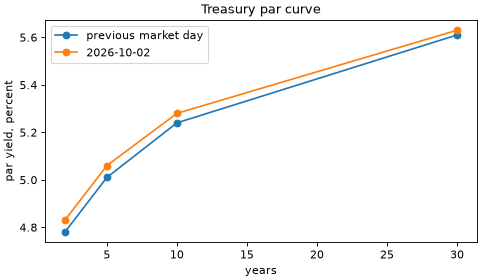

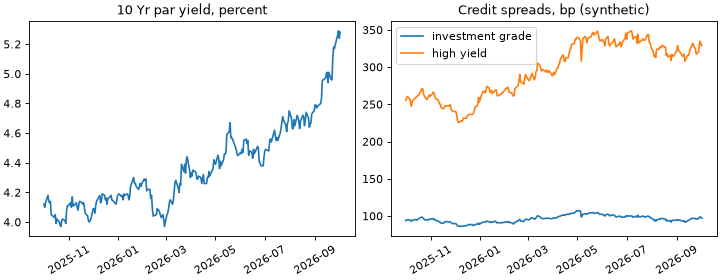

In [77]:
# the two charts, drawn again to show them here
for name, figure in snapshot.snapshot_figures(market, tables).items():
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=80)
    display(Image(buffer.getvalue()))

* The page holds the as-of date, the disclaimer, the source line, the synthetic label, 5 tables, and 2 charts inside the file itself: one file to send, with nothing linked. The workbook has one sheet per table, with the same numbers.
* Both are in `snapshots/`, which `.gitignore` keeps out of Git. They hold only public-domain and synthetic data, so they can be shared.

In [78]:
check('Question 7.6 sheets', answer_7_6a, '0d47bdf9a6d7')
check('Question 7.6 tables', answer_7_6b, 'c6e9ad310d27')

Question 7.6 sheets: correct
Question 7.6 tables: correct


### 7.7 snapshot.py, committed

Q. Show `git status --short --ignored`, then commit `snapshot.py` and show the history. The outputs are not committed.

In [79]:
# what Git sees, ignored files included (marked !!)
!git -C "{work}" status --short --ignored

?? snapshot.py
!! __pycache__/
!! snapshots/


In [80]:
!git -C "{work}" add snapshot.py
!git -C "{work}" commit -q -m "Deliverable 4: snapshot.py writes the daily snapshot for any market date"
!git -C "{work}" log --oneline

e73d149 Deliverable 4: snapshot.py writes the daily snapshot for any market date
96acd7b Deliverable 3: reconciliation of the extract against the source files
98b69d3 Deliverable 2: clean_extract cleans the vendor extract, with assert checks
26f5175 Deliverable 1: marketdata complete, every test passing


* `!! snapshots/` and `!! __pycache__/` are ignored, as the `.gitignore` of question 1.2 asked. `?? snapshot.py` is new, and the commit takes it.

## 8 Rerun, Do Not Redo

### 8.1 Deliverable 5: the snapshot for 2026-09-30

Q. Run `snapshot.py --as-of 2026-09-30` as a separate program with `subprocess.run([sys.executable, "snapshot.py", "--as-of", "2026-09-30"], cwd=work, capture_output=True, text=True)`, print what it prints, and `assert` that it returned 0. It rebuilds everything from the files: nothing from this notebook's memory. Read the 2026-09-30 workbook's `levels` sheet back into `levels_rerun`, and store its 10 Yr level in **answer_8_1**, to 2 decimal places.

In [81]:
run = subprocess.run([sys.executable, "snapshot.py", "--as-of", "2026-09-30"], cwd=work, capture_output=True, text=True)
print(run.stdout + run.stderr)
assert run.returncode == 0, "snapshot.py stopped"

rerun_book = pd.read_excel(Path("snapshots") / "snapshot_2026-09-30.xlsx", sheet_name=None, index_col=0)
levels_rerun = rerun_book["levels"]
answer_8_1 = levels_rerun.loc["10 Yr", "level"]
print(f"10 Yr on 2026-09-30: {answer_8_1:.2f} percent")

wrote snapshots/snapshot_2026-09-30.html
wrote snapshots/snapshot_2026-09-30.xlsx
2940 market days, the extract cleaned with 16 changes

10 Yr on 2026-09-30: 5.29 percent


* The same script, a different date, and no code changed: 5.29 percent on 2026-09-30, the value the Treasury file has for that date, not the last row of the market (day 14's AI check).

In [82]:
check('Question 8.1', answer_8_1, '949a28ab7b7f', places=2)

Question 8.1: correct


### 8.2 The two dates side by side

Q. Build a table with a row for each of the six series and columns `unit`, `2026-09-30`, `2026-10-02`, and `change_bp`, the level on 2026-10-02 less the level on 2026-09-30, in bp (times 100 for a yield in percent). Then read 2s10s from both workbooks' `slopes_flies` sheets, and store the pair (2026-09-30, 2026-10-02) as a tuple in **answer_8_2**, each to 1 decimal place.

In [83]:
latest_book = pd.read_excel(Path("snapshots") / "snapshot_2026-10-02.xlsx", sheet_name=None, index_col=0)
side = pd.DataFrame({"unit": levels_rerun["unit"], "2026-09-30": levels_rerun["level"], "2026-10-02": latest_book["levels"]["level"]})
scale = side["unit"].map({"pct": 100, "bp": 1})
side["change_bp"] = (side["2026-10-02"] - side["2026-09-30"]) * scale
print(side.round(2).to_string())

answer_8_2 = (rerun_book["slopes_flies"].loc["2s10s", "level"], latest_book["slopes_flies"].loc["2s10s", "level"])
print(f"2s10s: {answer_8_2[0]:.1f} bp on 2026-09-30, {answer_8_2[1]:.1f} bp on 2026-10-02")

             unit  2026-09-30  2026-10-02  change_bp
series                                              
2 Yr          pct        4.88        4.83       -5.0
5 Yr          pct        5.09        5.06       -3.0
10 Yr         pct        5.29        5.28       -1.0
30 Yr         pct        5.64        5.63       -1.0
ig_spread_bp   bp       98.80       97.00       -1.8
hy_spread_bp   bp      334.70      328.70       -6.0
2s10s: 41.0 bp on 2026-09-30, 45.0 bp on 2026-10-02


* From 2026-09-30 to 2026-10-02 every yield was lower: 2 Yr -5.0 bp, 5 Yr -3.0 bp, 10 Yr -1.0 bp, 30 Yr -1.0 bp. The synthetic spreads were lower too: investment grade -1.8 bp, high yield -6.0 bp. 2s10s went from 41.0 to 45.0 bp.
* The table says how each series changed between two dates, and nothing about why or what follows.

In [84]:
check('Question 8.2', answer_8_2, '74320e0b4938', places=1)

Question 8.2: correct


### 8.3 Deliverable 6: the snapshot history in SQL

Q. Stack both levels tables into one table with the columns `as_of` (text), `series`, `unit`, `level`, `chg_1d_bp`, `chg_1w_bp`, `chg_1m_bp`, `zscore`, and `pct_rank`; write it to `snapshots/snapshot_history.csv`; and load it into a table `snapshot_history` of `course3.db` with `md.load_tables` (day 11). Store the number of rows in the table in **answer_8_3**.

In [85]:
stacked = pd.concat([levels_rerun.assign(as_of="2026-09-30"), latest_book["levels"].assign(as_of="2026-10-02")])
stacked = stacked.reset_index()[["as_of", "series", "unit", "level", "chg_1d_bp", "chg_1w_bp", "chg_1m_bp", "zscore", "pct_rank"]]
stacked.to_csv(Path("snapshots") / "snapshot_history.csv", index=False)

db_path = Path("course3.db")
counts = md.load_tables(db_path, {"snapshot_history": Path("snapshots") / "snapshot_history.csv"})
answer_8_3 = counts["snapshot_history"]
print(f"snapshot_history: {answer_8_3} rows in {db_path.name}")

snapshot_history: 12 rows in course3.db


* 12 rows: six series on each of two dates. Each new day's snapshot adds six more, and the table becomes the history of the snapshot itself.

In [86]:
check('Question 8.3', answer_8_3, '6ba926b858fb')

Question 8.3: correct


### 8.4 Two queries, each checked against pandas

Q. Write `queries.sql` with `%%writefile`, holding two queries separated by `;`, each with a `--` comment above it and a `?` parameter wherever it takes a value: the six rows of one date, and the change of each series from one date to the other in bp (a self-join of `snapshot_history`, with `CASE` for the units). Run each with `md.run_query`, compare each with its pandas equivalent with `md.assert_same_rows`, and store the high yield spread's change in bp from the second query in **answer_8_4**, to 1 decimal place.

In [87]:
%%writefile queries.sql
-- the six series of one snapshot date
SELECT series, unit, level, chg_1d_bp
FROM snapshot_history
WHERE as_of = ?
ORDER BY series;

-- the change of each series from one snapshot date to another, in bp: times 100 for a yield in percent
SELECT a.series, a.unit, a.level AS level_from, b.level AS level_to,
       (b.level - a.level) * CASE WHEN a.unit = 'pct' THEN 100 ELSE 1 END AS change_bp
FROM snapshot_history AS a
JOIN snapshot_history AS b ON a.series = b.series
WHERE a.as_of = ? AND b.as_of = ?
ORDER BY a.series;

Writing queries.sql


In [88]:
# the file holds two queries; split on ";" and keep the ones that are not empty
queries = [text.strip() for text in Path("queries.sql").read_text(encoding="utf-8").split(";") if text.strip()]

one_date = md.run_query(db_path, queries[0], ("2026-10-02",))
one_date_pandas = stacked.loc[stacked["as_of"] == "2026-10-02", ["series", "unit", "level", "chg_1d_bp"]]
md.assert_same_rows(one_date, one_date_pandas, sort_by=["series"])

change = md.run_query(db_path, queries[1], ("2026-09-30", "2026-10-02"))
pairs = stacked[stacked["as_of"] == "2026-09-30"].merge(stacked[stacked["as_of"] == "2026-10-02"], on=["series", "unit"],
                                                       suffixes=("_from", "_to"), validate="one_to_one")
change_pandas = pd.DataFrame({"series": pairs["series"], "unit": pairs["unit"], "level_from": pairs["level_from"],
                              "level_to": pairs["level_to"],
                              "change_bp": (pairs["level_to"] - pairs["level_from"]) * pairs["unit"].map({"pct": 100, "bp": 1})})
md.assert_same_rows(change, change_pandas, sort_by=["series"])

answer_8_4 = change.set_index("series").loc["hy_spread_bp", "change_bp"]
print("Both queries equal their pandas equivalents")
print(change.round(2).to_string(index=False))

Both queries equal their pandas equivalents
      series unit  level_from  level_to  change_bp
       10 Yr  pct        5.29      5.28       -1.0
        2 Yr  pct        4.88      4.83       -5.0
       30 Yr  pct        5.64      5.63       -1.0
        5 Yr  pct        5.09      5.06       -3.0
hy_spread_bp   bp      334.70    328.70       -6.0
ig_spread_bp   bp       98.80     97.00       -1.8


* Both queries agree with pandas, row for row, within the course's tolerance for floats. The high yield spread changed by -6.0 bp, as the side-by-side table of question 8.2 said: three routes to one number.
* The dates went in as `?` parameters, never pasted into the SQL text (day 11).

In [89]:
check('Question 8.4', answer_8_4, '9082e0f5372a', places=1)

Question 8.4: correct


### 8.5 queries.sql, committed

Q. Check that `course3.db` is ignored with `git check-ignore -v`, then commit `queries.sql` and show the history.

In [90]:
!git -C "{work}" check-ignore -v course3.db
!git -C "{work}" add queries.sql
!git -C "{work}" commit -q -m "Deliverable 6: the two snapshots' levels in SQL, checked against pandas"
!git -C "{work}" log --oneline

.gitignore:4:*.db	course3.db


48b0a7a Deliverable 6: the two snapshots' levels in SQL, checked against pandas


e73d149 Deliverable 4: snapshot.py writes the daily snapshot for any market date
96acd7b Deliverable 3: reconciliation of the extract against the source files
98b69d3 Deliverable 2: clean_extract cleans the vendor extract, with assert checks
26f5175 Deliverable 1: marketdata complete, every test passing


## 9 Live, With Your Own Key (Optional)

*This product uses the FRED&reg; API but is not endorsed or certified by the Federal Reserve Bank of St. Louis.*

This section is optional and has no checks. Every cell runs without a key, and the saved notebook was run without one, so each prints the skip message. With your key in `my_bondmath\.env`, in an environment variable, or in Colab's Secrets panel (day 1), the key cell finds it and the live cells pull from FRED.

Nothing here is written to a file. ICE BofA and Moody's values stay off the screen unless you set `SHOW_LICENSED_VALUES` to `True` on your own machine: their providers' terms do not allow them to be published (day 5).

Q. Run the key cell.

In [91]:
try:
    fred_key = md.get_secret("FRED_API_KEY", env_file=ENV_FILE)
    print("FRED key: found. It is held in memory and is never printed.")
except RuntimeError as error:
    fred_key = None
    print(f"FRED key: not found. Live cells will be skipped. {error}")

FRED key: not found. Live cells will be skipped. Secret FRED_API_KEY not found. Looked in: the environment variable FRED_API_KEY, Colab's Secrets panel, and the file .env given as env_file.


Q. Pull the 3 Mo, 2 Yr, 5 Yr, 10 Yr, and 30 Yr from FRED from 2015, check them against the Treasury file for the extract's period, then build the snapshot tables for 2026-09-30 from FRED's curve and the synthetic spreads, and compare the levels with the same tables built from the source files.

In [92]:
# a live cell: it needs your key and the network
if fred_key is None:
    print(NO_KEY_MESSAGE)
else:
    # the curve fresh from FRED, in percent; "." rows are NaN, then dropped (the days the Treasury file has no row)
    live_ids = {"DGS3MO": "3 Mo", "DGS2": "2 Yr", "DGS5": "5 Yr", "DGS10": "10 Yr", "DGS30": "30 Yr"}
    live_curve = pd.DataFrame({column: md.fred_series(series_id, fred_key, start="2015-01-01")
                               for series_id, column in live_ids.items()}).dropna()
    print(f"FRED: {len(live_curve):,} market days of {len(live_ids)} tenors, {live_curve.index[0]:%Y-%m-%d} to {live_curve.index[-1]:%Y-%m-%d}")

    # check 1: every value equals the Treasury file on every date both have in the extract's period
    live_period = live_curve.loc[period_start:period_end]
    live_gap = (live_period - source.loc[live_period.index, live_period.columns]).abs().max().max()
    assert len(live_period) > 0 and live_gap <= 1e-9, "FRED and the Treasury file disagree"
    print(f"Extract period: {len(live_period)} days in both, largest gap {live_gap:.1e} percent")

    # check 2: the snapshot's levels from FRED's curve and the synthetic spreads equal those from the source files
    live_units = {"2 Yr": "pct", "5 Yr": "pct", "10 Yr": "pct", "30 Yr": "pct", "ig_spread_bp": "bp", "hy_spread_bp": "bp"}
    live_market = live_curve.join(source[SPREAD_COLUMNS], how="inner")
    live_levels = md.snapshot_tables(live_market, september, "2026-09-30", live_units)["levels"]
    live_reference = md.snapshot_tables(source[list(live_ids.values()) + SPREAD_COLUMNS], september, "2026-09-30", live_units)["levels"]
    live_levels_gap = (live_levels.drop(columns="unit") - live_reference.drop(columns="unit")).abs().max().max()
    assert live_levels_gap <= 1e-9, "the snapshot from FRED differs from the snapshot from the files"
    print(f"Snapshot levels for 2026-09-30: FRED against the files, largest gap {live_levels_gap:.1e}")

Live cell skipped: no FRED key was found. Every other cell runs without one.


* The saved output is the skip message, because the saved run had no key.
* **With your key** you will see the number of market days FRED returned for the five tenors, from 2015-01-02 to a day or two before the day you run it, then two check lines: on every day of the extract's period FRED equals the Treasury file, and the snapshot's levels for 2026-09-30 built from FRED's curve equal those built from the files. FRED's `DGS` series and the Treasury file are the same data, published by Treasury.
* No URL and no key appear: `md.fred_series` never prints either, and its errors name only the series and the status.

Q. Pull the ICE BofA investment grade and high yield spreads and Moody's Baa spread, and print what describes each series, never its values.

In [93]:
# a live cell: it needs your key and the network
if fred_key is None:
    print(NO_KEY_MESSAGE)
else:
    # licensed series: metadata only. Values only under SHOW_LICENSED_VALUES, which stays False in this notebook.
    for live_id in ["BAMLC0A0CM", "BAMLH0A0HYM2", "BAA10Y"]:
        live_series = md.fred_series(live_id, fred_key)
        live_weekend = int((live_series.index.dayofweek >= 5).sum())
        print(f"{live_id}: percent, {len(live_series):,} rows, {live_series.index[0]:%Y-%m-%d} to {live_series.index[-1]:%Y-%m-%d}, "
              f"{int(live_series.isna().sum())} '.' rows, {live_weekend} weekend rows")
        assert len(live_series) > 0, f"{live_id} came back empty"
        if SHOW_LICENSED_VALUES:
            # for your own screen only: the last five values, converted from percent to bp
            print((live_series.dropna().tail(5) * 100).round(1).to_string())

Live cell skipped: no FRED key was found. Every other cell runs without one.


* **With your key** you will see, for each series, its units, its number of rows, its first and last date, how many weekdays carry `.`, and how many rows fall on a weekend. The ICE series hold about three years of daily rows ending a day or two before you run the cell; Moody's starts in 1986. No value is printed.
* The snapshot in this capstone uses the synthetic spreads for exactly this reason: it is meant to be shared, and these values may not be.

## 10 The Log and the Description

### 10.1 Deliverable 8: the AI-use log

Q. Fill in the log in the cell below, one row for each time you asked an AI assistant for help with the capstone: what you asked, what you accepted or rejected, and how you checked it. If you used none, write `none used` in the first row. That is a valid entry. Run the cell: it writes `ai_use_log.md` in the work folder. Then commit it.

What never goes into an AI tool, or into a cloud notebook such as Colab: a key or a URL with a key in it, client names, positions, anything from your employer, and licensed data. Describe the columns and the task, and keep the rows out. Your firm's policy comes before anything said here. There is no check cell for this question.

In [94]:
%%writefile ai_use_log.md
# AI-use log

An example of a filled-in log, written for this course to show the level of detail to aim for.

| What I asked | What I accepted or rejected | How I checked it |
| --- | --- | --- |
| How to read a date column that mixes two formats | Accepted reading each format with `errors="coerce"` and combining with `fillna`. Rejected `format="mixed"`, because it would read a day-first date as month-first without a word | Counted the rows each format read, and asserted none was left |
| A docstring for `clean_extract` that lists its decisions, given my code | Accepted the numbered list. Rejected a line that said missing days are "filled forward for continuity", because the desk's rule is to restore them from the source | Read every line against the code, then ran the checkpoint and the reconciliation |
| How to compare a SQL result with a pandas table when the row order differs | Accepted sorting both by the key and resetting the index, which `md.assert_same_rows` already does | Ran it on two tables typed by hand, one with a value changed |

No row of the extract and no key went into the assistant. Each question described the columns and the task.

Writing ai_use_log.md


In [95]:
!git -C "{work}" add ai_use_log.md
!git -C "{work}" commit -q -m "Deliverable 8: the AI-use log"
!git -C "{work}" log --oneline

70c876c Deliverable 8: the AI-use log
48b0a7a Deliverable 6: the two snapshots' levels in SQL, checked against pandas
e73d149 Deliverable 4: snapshot.py writes the daily snapshot for any market date
96acd7b Deliverable 3: reconciliation of the extract against the source files
98b69d3 Deliverable 2: clean_extract cleans the vendor extract, with assert checks
26f5175 Deliverable 1: marketdata complete, every test passing


### 10.2 Deliverable 9: the written description

Q. Write the page for the portfolio manager in the cell below, in 300 to 450 words of markdown, and run it: it writes `description.md`. Then run the two cells after it: the first defines `assert_descriptive`, which stops on a short list of words that forecast or advise; the second checks your page with it and displays it. Then commit it. Use this outline:

1. **Levels.** The four yields, the two synthetic spreads, and 2s10s on each date, each with its unit.
2. **Changes.** The one-day, one-week, and one-month changes to 2026-10-02, in bp.
3. **Where each sits in its one-year history.** Percentile ranks and z-scores over 252 market days.
4. **The book.** The September book's DV01, and the mechanical what-if on each date.
5. **The data.** Each problem found in the extract, in how many rows, what was done, and the evidence; the reconciliation; what is not on the snapshot and why.

The rule, once more: **describe, never forecast.** Every sentence says what the data was, where it sits in its history, or how it changed. No sentence says where a yield or a spread is going, what a level means for the future, or what anyone should do. The word list is a reminder, not a proof: a sentence can forecast without any of its words. There is no check cell for this question.

In [96]:
%%writefile description.md
# Two days of the market: 2026-09-30 and 2026-10-02

The Treasury yields are public data from the U.S. Treasury. The credit spreads and the book are synthetic, invented for this course; the spreads are not ICE, Moody's, or any index.

**Levels.** On 2026-10-02 the par yields were 4.83 percent at 2 years, 5.06 at 5, 5.28 at 10, and 5.63 at 30. On 2026-09-30 they were 4.88, 5.09, 5.29, and 5.64, so between the two dates they moved by -5.0, -3.0, -1.0, -1.0 bp. The synthetic investment grade spread was 97.0 bp against 98.8, and the high yield spread 328.7 bp against 334.7. 2s10s was 45.0 bp against 41.0.

**Changes to 2026-10-02.** The 10 Yr changed by +4.0 bp on the day, +11.0 bp over a week, and +49.0 bp over a month; the 2 Yr by +44.0 bp over the month. The high yield spread changed by -1.3 bp on the day and +0.1 bp over the month.

**Where each sits in its one-year history.** Over the last 252 market days, the four yields on 2026-10-02 had percentile ranks from 98.0 to 99.6 and z-scores from 2.51 to 3.08. The investment grade spread had a percentile rank of 61.1 (z-score 0.22), high yield 73.8 (0.90), and 2s10s 28.2 (-0.51).

**The book.** The September book, 200 bonds and 490.82 million dollars of market value, has a DV01 of 306,996.11 dollars per bp. If each bond's yield had moved by the day's curve change at its maturity, its market value would have changed by -1,179,287.02 dollars on 2026-10-02 and -969,059.01 dollars on 2026-09-30. This is a mechanical what-if built from the four tenors the extract carries; on the Treasury file's full curve the 2026-10-02 figure is -1,193,297.89 dollars.

**The data.** The vendor's extract had 69 rows for the cover note's 66 market days. `clean_extract` found and fixed: 3 dates written MM/DD/YYYY, read with that format; 2 exact duplicate rows, removed; 1 holiday row of `.` values, dropped; 1 Saturday row repeating the Friday, dropped; 1 market day with no row, restored from the source files; 2 yields sent in bp, divided by 100; 2 spreads sent in percent, multiplied by 100; a stale run of 5 identical hy_spread_bp values, whose 4 repeats were restored from the source files. All 13 differences between the extract as received and the source files are decisions of `clean_extract`; none is unexplained. The cleaned extract equals the source files on all 66 market days and matches the cover note's last values. The extract carries no 3 Mo yield, so 3m10y is not on either snapshot.

**Open items.** The vendor to confirm the corrected rows and to resend the hy_spread_bp values from 2026-07-28.

Writing description.md


In [97]:
# words that forecast or advise. The list is a reminder, not a proof: a sentence can forecast without any of them.
FORECAST_WORDS = ['will', 'expect', 'expects', 'expected', 'should', 'cheap', 'rich', 'attractive', 'signal', 'buy', 'sell', 'likely', 'outlook', 'recommend', 'overweight', 'underweight']


def assert_descriptive(text):
    """Stop if the text uses a word from FORECAST_WORDS, as a whole word, in any capitals."""
    found = sorted({word.lower() for word in re.findall(r"\b(" + "|".join(FORECAST_WORDS) + r")\b", text, flags=re.I)})
    assert not found, f"words that forecast or advise: {found}. Describe what the data shows instead."
    print(f"No word from the list of {len(FORECAST_WORDS)}. Read it once more for meaning: the list is a reminder.")

In [98]:
# check the page against the word list, then show it as formatted text
page_text = Path("description.md").read_text(encoding="utf-8")
assert_descriptive(page_text)
body = page_text.split("\n", 1)[-1]
n_words = len(re.findall(r"[A-Za-z0-9]\S*", body))
print(f"{n_words} words after the title")
display(Markdown(page_text))

No word from the list of 16. Read it once more for meaning: the list is a reminder.
436 words after the title


# Two days of the market: 2026-09-30 and 2026-10-02

The Treasury yields are public data from the U.S. Treasury. The credit spreads and the book are synthetic, invented for this course; the spreads are not ICE, Moody's, or any index.

**Levels.** On 2026-10-02 the par yields were 4.83 percent at 2 years, 5.06 at 5, 5.28 at 10, and 5.63 at 30. On 2026-09-30 they were 4.88, 5.09, 5.29, and 5.64, so between the two dates they moved by -5.0, -3.0, -1.0, -1.0 bp. The synthetic investment grade spread was 97.0 bp against 98.8, and the high yield spread 328.7 bp against 334.7. 2s10s was 45.0 bp against 41.0.

**Changes to 2026-10-02.** The 10 Yr changed by +4.0 bp on the day, +11.0 bp over a week, and +49.0 bp over a month; the 2 Yr by +44.0 bp over the month. The high yield spread changed by -1.3 bp on the day and +0.1 bp over the month.

**Where each sits in its one-year history.** Over the last 252 market days, the four yields on 2026-10-02 had percentile ranks from 98.0 to 99.6 and z-scores from 2.51 to 3.08. The investment grade spread had a percentile rank of 61.1 (z-score 0.22), high yield 73.8 (0.90), and 2s10s 28.2 (-0.51).

**The book.** The September book, 200 bonds and 490.82 million dollars of market value, has a DV01 of 306,996.11 dollars per bp. If each bond's yield had moved by the day's curve change at its maturity, its market value would have changed by -1,179,287.02 dollars on 2026-10-02 and -969,059.01 dollars on 2026-09-30. This is a mechanical what-if built from the four tenors the extract carries; on the Treasury file's full curve the 2026-10-02 figure is -1,193,297.89 dollars.

**The data.** The vendor's extract had 69 rows for the cover note's 66 market days. `clean_extract` found and fixed: 3 dates written MM/DD/YYYY, read with that format; 2 exact duplicate rows, removed; 1 holiday row of `.` values, dropped; 1 Saturday row repeating the Friday, dropped; 1 market day with no row, restored from the source files; 2 yields sent in bp, divided by 100; 2 spreads sent in percent, multiplied by 100; a stale run of 5 identical hy_spread_bp values, whose 4 repeats were restored from the source files. All 13 differences between the extract as received and the source files are decisions of `clean_extract`; none is unexplained. The cleaned extract equals the source files on all 66 market days and matches the cover note's last values. The extract carries no 3 Mo yield, so 3m10y is not on either snapshot.

**Open items.** The vendor to confirm the corrected rows and to resend the hy_spread_bp values from 2026-07-28.


In [99]:
!git -C "{work}" add description.md
!git -C "{work}" commit -q -m "Deliverable 9: the written description of the two dates"
!git -C "{work}" log --oneline

60a0b17 Deliverable 9: the written description of the two dates
70c876c Deliverable 8: the AI-use log
48b0a7a Deliverable 6: the two snapshots' levels in SQL, checked against pandas
e73d149 Deliverable 4: snapshot.py writes the daily snapshot for any market date
96acd7b Deliverable 3: reconciliation of the extract against the source files
98b69d3 Deliverable 2: clean_extract cleans the vendor extract, with assert checks
26f5175 Deliverable 1: marketdata complete, every test passing


## Excel Side by Side

Every formula below was typed into desktop Excel for Windows and its result read back (tested in Excel). The extract is pasted as text into A1:G70, with the header in row 1 and each value kept as the vendor wrote it.

| Check | Python | Excel (tested), in row 2 and filled down | Excel returns |
| --- | --- | --- | --- |
| Rule 2: the date reads as `YYYY-MM-DD` | `pd.to_datetime(..., format="%Y-%m-%d", errors="coerce")` | `=DATE(LEFT(A2,4),MID(A2,6,2),RIGHT(A2,2))` in column H | `#VALUE!` on the 3 rows written MM/DD/YYYY |
| Rule 3: a weekend date | `dt.dayofweek >= 5` | `=WEEKDAY(H2,2)>5` in column I | `TRUE` on 1 row |
| Rule 1: a date that repeats | `duplicated()` | `=COUNTIF($A$2:$A$70,A2)` in column J | 2 on 4 rows |
| Rule 5: `.` as missing, never 0 | `.where(... != ".")` | `=IFERROR(VALUE(B2),NA())` in column K | `#N/A` on 1 row |
| Rule 6: a yield above 25 | `> 25` | `=IFERROR(VALUE(C2),NA())>25` in column L | `TRUE` on 2 rows |
| Rule 6: an investment grade spread below 10 | `< 10` | `=IFERROR(VALUE(F2),NA())<10` in column M | `TRUE` on 1 row |
| Rule 6: a high yield spread below 10 | `< 10` | `=IFERROR(VALUE(G2),NA())<10` in column N | `TRUE` on 1 row |

`DATE(LEFT(...),MID(...),RIGHT(...))` builds a date from the pieces of `YYYY-MM-DD` text: the same test as the single format of question 2.3. `IFERROR(VALUE(...),NA())` turns `.` into `#N/A`, Excel's own mark for no value, where a 0 would be a number. `WEEKDAY(...,2)` counts Monday as 1, so above 5 is a weekend.

**The snapshot workbook in Excel (tested in Excel).** Open `snapshot_2026-10-02.xlsx` with the PowerShell line that question 7.6 printed (change `.html` to `.xlsx`). Each table is a tab, with its row labels in column A and the column names in row 1; every cell holds a value, none a formula, because pandas wrote numbers. Formulas typed into empty cells reproduce three of its numbers:

| Snapshot figure | Excel (tested) | Same as |
| --- | --- | --- |
| The curve's change in bp, tenor by tenor | `=(D2-C2)*100` on the `curve` tab, filled down | its `chg_bp` column, E |
| The book's DV01 | `=SUMIFS(G:G,B:B,"sector")` on the `book` tab | the `dv01_usd` of the `total` row |
| The book's what-if | `=SUMIFS(H:H,B:B,"sector")` on the `book` tab | the `mv_change_usd` of the `total` row |

* Excel showed the tabs `levels`, `curve`, `slopes_flies`, `book`, `notes`, with no formula on any of them; the 10 Yr level on `levels` read 5.28 and the high yield percentile rank 73.80952380952381, the notebook's values. The curve formula equalled `chg_bp` on every tenor (largest gap 8.9e-16 bp); the DV01 sum returned 306,996.110402 and the what-if sum -1,179,287.022646, equal to the `total` row within 5.8e-11.

## Save the Day with Git

### Deliverable 7: the history

Q. Show the history with `git log --oneline`: one commit for each deliverable that writes a file. Store the number of commits in **answer_git**. Then tag the last commit `course3`, and show the history with its names.

In [100]:
# one line per commit, newest first
!git -C "{work}" log --oneline

60a0b17 Deliverable 9: the written description of the two dates


70c876c Deliverable 8: the AI-use log
48b0a7a Deliverable 6: the two snapshots' levels in SQL, checked against pandas
e73d149 Deliverable 4: snapshot.py writes the daily snapshot for any market date
96acd7b Deliverable 3: reconciliation of the extract against the source files
98b69d3 Deliverable 2: clean_extract cleans the vendor extract, with assert checks
26f5175 Deliverable 1: marketdata complete, every test passing


In [101]:
# count the commits: one line each in git log --oneline
history_log = subprocess.run(["git", "-C", str(work), "log", "--oneline"], capture_output=True, text=True, check=True).stdout
answer_git = len(history_log.strip().splitlines())
print(f"Commits: {answer_git}")

Commits: 7


In [102]:
# name the last commit, then show the names
!git -C "{work}" tag course3
!git -C "{work}" log --oneline --decorate

60a0b17 (HEAD -> main, tag: course3) Deliverable 9: the written description of the two dates
70c876c Deliverable 8: the AI-use log
48b0a7a Deliverable 6: the two snapshots' levels in SQL, checked against pandas
e73d149 Deliverable 4: snapshot.py writes the daily snapshot for any market date
96acd7b Deliverable 3: reconciliation of the extract against the source files
98b69d3 Deliverable 2: clean_extract cleans the vendor extract, with assert checks
26f5175 Deliverable 1: marketdata complete, every test passing


* 7 commits, one for each deliverable that is a file: the module, `clean_extract`, the reconciliation, `snapshot.py`, the queries, the log, and the description. Deliverable 5 wrote only snapshot outputs, which stay ignored. The history is deliverable 7.
* `course3` names the commit that ends the course, as `week1` and `week2` named the ends of the weeks.

In [103]:
check('Question Git', answer_git, '2a4dfbe117ab')

Question Git: correct


## Bring It Home

Bring the capstone into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder, and check that your module still passes.

```powershell
Set-Location "$HOME\projects\my_bondmath"
python -m pytest -q test_marketdata.py
```

**Step 2.** Copy the two scripts, the queries, the files `snapshot.py` reads, and the snapshots from the work folder. The setup cell printed its name, `pfi_course3_15_` and eight more characters: put it in place of `<work folder>`.

```powershell
$work = "$env:TEMP\<work folder>"
Copy-Item "$work\clean_extract.py", "$work\snapshot.py", "$work\queries.sql" .
Copy-Item "$work\treasury_par_yields.csv", "$work\course3_synthetic_spreads.csv", "$work\course3_capstone_extract.csv", "$work\holdings.csv" .
Copy-Item "$work\snapshots" . -Recurse
```

**Step 3.** Run the snapshot from your own folder for a market date inside the extract's period, then commit the scripts. `snapshots/` stays ignored: if your `.gitignore` has no `snapshots/` line yet, add one first (day 14 did).

```powershell
python snapshot.py --as-of 2026-09-30
git add clean_extract.py snapshot.py queries.sql
git commit -m "Course 3 capstone: clean_extract, snapshot.py, and the snapshot queries"
git tag course3
git log --oneline --decorate
```

`snapshot.py` imports `marketdata` and `clean_extract` from the same folder, so it runs there as it ran in the notebook. Your `.env` and your key stay where they are: `snapshot.py` never needs them.

**In Colab**, download `clean_extract.py`, `snapshot.py`, and the files in `snapshots/` from the work folder under `/tmp` in the file browser. If Excel opens the downloaded workbook in Protected View, choose Enable Editing.

## You Can Now

* Test a vendor's extract against its cover note, the market's own calendar, and the desk's rules, and say what each rule found.
* Read dates written two ways, remove copies, drop the days the market was shut, and find a day that is missing.
* Find values in the wrong units and values that stopped updating, and say how each could be recovered.
* Package the decisions as `clean_extract`, with asserts that make it safe to rerun and a log that hides nothing.
* Reconcile the extract against the source with every difference explained, and prove the cleaned data equal to it.
* Append new data to history and show that the windows across the join are unchanged.
* Produce the daily snapshot as HTML and Excel from a script, for any market date, and keep its history in SQL.
* Keep every deliverable in Git, and write a page that describes two dates without forecasting anything.

## Exercises

The capstone's questions are its exercises. One more, last, as on every day of the course.

### The AI check

You ask an AI assistant for one step of `clean_extract`, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
def complete_days(extract, source):
    """Give the extract one row for every market day of its period, and no other row.

    extract has a DatetimeIndex named date and the six value columns, with the holiday and weekend rows already
    dropped. source is the clean market history (the Treasury file joined to the synthetic spreads), whose dates
    are the market calendar. A market day the extract lacks is taken from source, never filled from a neighbour:
    a filled value is a value the market never printed, and it makes a change of zero.
    Returns a new DataFrame; extract is not changed.
    """
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a data bug.

* The bug: `pd.bdate_range` is every weekday, not the market calendar, and `ffill()` fills every gap from the day before. On the test data it returned 68 rows for 66 market days: 2 weekdays the market was shut, each carrying the day before's values, and the market day taken out, filled from the day before. That made 3 days on which every value changed by exactly 0: rows the market never printed, and changes that never happened.
* The fix, in the cell below: the calendar is the source's own dates, and a missing market day comes from the source.

In [104]:
def complete_days(extract, source):
    """Give the extract one row for every market day of its period, and no other row.

    extract has a DatetimeIndex named date and the six value columns, with the holiday and weekend rows already
    dropped. source is the clean market history (the Treasury file joined to the synthetic spreads), whose dates
    are the market calendar. A market day the extract lacks is taken from source, never filled from a neighbour:
    a filled value is a value the market never printed, and it makes a change of zero.
    Returns a new DataFrame; extract is not changed.
    """
    # the market calendar is the source's own dates, never a list of weekdays
    market_days = source.loc[extract.index[0]:extract.index[-1]].index
    # a market day with no row comes from the source, not from the day before
    missing = market_days.difference(extract.index)
    completed = pd.concat([extract, source.loc[missing, extract.columns]]).sort_index()
    return completed.loc[market_days]

Q. The test data: the clean source for the period, with one market day taken out.

In [105]:
test_days = source.loc["2026-07-01":"2026-10-02", VALUE_COLUMNS]
test_input = test_days.drop(pd.Timestamp("2026-08-26"))
print(f"{len(test_days)} market days in the period; the test input has {len(test_input)}")

66 market days in the period; the test input has 65


In [106]:
completed = complete_days(test_input, source)

# the dates must be the market calendar, and every value the source's
extra = completed.index.difference(test_days.index)
missing = test_days.index.difference(completed.index)
assert extra.empty and missing.empty, f"{len(extra)} dates that are not market days, {len(missing)} market days missing"
gap = (completed - test_days).abs().max().max()
assert gap <= 1e-9, f"a value differs from the source by {gap}"
print(f"{len(completed)} rows, the market days of the period, every value equal to the source")

66 rows, the market days of the period, every value equal to the source


In [107]:
# the assistant's version, kept for comparison: every weekday, then filled forward
assistant_version = test_input.reindex(pd.bdate_range(test_input.index[0], test_input.index[-1], name="date")).ffill()
ai_added_rows = len(assistant_version.index.difference(test_days.index))
ai_rows_fixed = len(complete_days(test_input, source))
zero_days = (assistant_version.diff() == 0).all(axis=1).sum()
print(f"Assistant's version: {len(assistant_version)} rows, {ai_added_rows} not market days, {zero_days} days with every change exactly 0")
print(f"Fixed version: {ai_rows_fixed} rows")

Assistant's version: 68 rows, 2 not market days, 3 days with every change exactly 0
Fixed version: 66 rows


* 2 rows that are not market days, and 66 rows once fixed: the period's market days. None of the capstone's other checks would see the bug if this step ran after them: the rows are weekdays, in the right units, with no `.`. A test against the market's own calendar is what catches it.

In [108]:
check('AI check rows that are not market days', ai_added_rows, '54b9de6129cc')
check('AI check rows after the fix', ai_rows_fixed, 'da466b3029b9')

AI check rows that are not market days: correct
AI check rows after the fix: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```